# VTT Pipeline — Paper Analysis
**BC Cancer · QURIT Lab · Peter Yazdi**

Provide `CT_DIR` and `OUTPUT_TITLE` below. The notebook discovers all patient output folders automatically, displays every pipeline stage output, runs three SPECT comparison studies (TAC differences, bi-exponential kinetics, AUC), and plots CPU/RAM profiling data.

---

## 1 — Imports & Style

In [72]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from scipy.optimize import curve_fit

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.labelweight': 'bold',
    'figure.titlesize': 16, 'figure.titleweight': 'bold',
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 100,
})

def _strip_comments(text):
    lines = []
    for line in text.splitlines():
        idx = line.find('//')
        lines.append(line[:idx] if idx >= 0 else line)
    return '\n'.join(lines)

def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.loads(_strip_comments(f.read()))

def arr_aspect(sp, view):
    if view == 'axial':    return sp[1] / sp[0]
    if view == 'coronal':  return sp[2] / sp[0]
    if view == 'sagittal': return sp[2] / sp[1]
    return 'auto'

def pct(numer, denom, eps=1e-9):
    return (numer - denom) / (abs(denom) + eps) * 100.0

def list_files(directory, suffix):
    if not os.path.isdir(directory):
        return []
    return sorted(os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(suffix))

def stem(path):
    name = os.path.basename(path)
    return name[:-7] if name.endswith('.nii.gz') else os.path.splitext(name)[0]

print('Imports OK')

Imports OK


---
## 2 — User Parameters

In [73]:
# ── INPUT ──────────────────────────────────────────────────────────────────────
CT_DIR       = "/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/inputs/ct_testing"
OUTPUT_TITLE = "cpu_testing"
OUTPUT_ROOT  = "/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline"

# ── COMPARISON CONTROLS ────────────────────────────────────────────────────────
SKIP_ROIS_COMPARISON = {'body', 'remaining_body', 'background'}
SKIP_LAST_FRAME      = True

# ── PROFILING ─────────────────────────────────────────────────────────────────
PROFILE_PHASE  = ""
PARAM_LABEL    = "Patient"

# ── AUTO DISCOVERY ────────────────────────────────────────────────────────────
prefix = OUTPUT_TITLE + '_CT_'
folder_names = sorted(
    [d for d in os.listdir(OUTPUT_ROOT)
     if os.path.isdir(os.path.join(OUTPUT_ROOT, d)) and d.startswith(prefix)],
    key=lambda name: int(name.split('_CT_')[-1])
)
OUT_FOLDERS = [os.path.join(OUTPUT_ROOT, d) for d in folder_names]
N = len(OUT_FOLDERS)

if N == 0:
    raise RuntimeError(f"No folders matching '{prefix}*' in {OUTPUT_ROOT}")

ct_inputs = []
if os.path.isdir(CT_DIR):
    for entry in sorted(os.listdir(CT_DIR)):
        p = os.path.join(CT_DIR, entry)
        if os.path.isdir(p) or entry.endswith(('.nii', '.nii.gz')):
            ct_inputs.append(p)

print(f"Found {N} output folder(s):")
for i, f in enumerate(OUT_FOLDERS):
    ct_str = ct_inputs[i] if i < len(ct_inputs) else '(unknown)'
    print(f"  CT {i+1}: {os.path.basename(f)}  \u2190  {os.path.basename(ct_str)}")

Found 2 output folder(s):
  CT 1: cpu_testing_CT_1  ←  p1
  CT 2: cpu_testing_CT_2  ←  p2


---
## 3 — Phase 1: Digital Twin
For each patient: config summary → input CT → unified segmentation → synthetic lesions → PBPK TACs.

In [74]:
configs = {}

for i, folder in enumerate(OUT_FOLDERS):
    cfg_path = os.path.join(folder, 'config.json')
    if os.path.exists(cfg_path):
        configs[i] = load_json(cfg_path)

    print(f"{'═'*62}")
    print(f"  CT {i+1}: {os.path.basename(folder)}")
    print(f"{'═'*62}")

    if i not in configs:
        print("  (config.json not found)"); continue

    cfg   = configs[i]
    p1    = cfg.get('phase_1', {})
    p2    = cfg.get('phase_2', {})
    p3    = cfg.get('phase_3', {})
    seg   = p1.get('segmentation_stage', {})
    les   = p1.get('synthetic_lesions_stage', {})
    pbpk  = p1.get('pbpk_tac_stage', {})
    sim   = p2.get('simind_stage', {})
    og    = p2.get('opengate_stage', {})
    spect = p3.get('spect_postprocess_stage', {})
    dose  = p3.get('dosemap_postprocess_stage', {})

    print(f"\n  ┌─ Phase 1: Digital Twin {'─'*35}")
    print(f"  │  ROIs segmented     : {seg.get('roi_subset', [])}")
    specs = les.get('specs', {})
    if specs:
        for organ, s in specs.items():
            print(f"  │  Synthetic lesions  : {organ} — {s.get('n_lesions', 0)} lesion(s), "
                  f"radii={s.get('radii_mm')} mm, prob={s.get('prob', '—')}")
    else:
        print(f"  │  Synthetic lesions  : none")
    print(f"  │  PBPK model         : {pbpk.get('model_type', '—')}  isotope={pbpk.get('isotope', '—')}")

    print(f"  ├─ Phase 2: Simulations {'─'*34}")
    print(f"  │  SIMIND")
    print(f"  │    isotope          : {sim.get('isotope', '—')}")
    print(f"  │    collimator       : {sim.get('Collimator', '—')}")
    print(f"  │    ROI subset       : {sim.get('roi_subset', 'all ROIs')}")
    print(f"  │    photons          : {sim.get('NumPhotons', '—'):,}")
    print(f"  │    projections      : {sim.get('NumProjections', '—')}  output px = {sim.get('OutputPixelWidth', '—')} cm")
    print(f"  │  OpenGATE")
    print(f"  │    ROI subset       : {og.get('roi_subset', 'all ROIs')}")
    print(f"  │    total histories  : {og.get('gate', {}).get('total_histories', '—'):,}")
    print(f"  │    variance reduc.  : {og.get('variance_reduction', False)}")

    print(f"  └─ Phase 3: Post-Processing {'─'*31}")
    ft    = spect.get('FrameStartTimes', [])
    fd    = spect.get('FrameDurations', [])
    ft_hr = [f'{t/60:.2f}h' for t in ft]
    print(f"     SPECT frames       : {len(ft)} — start times = {ft_hr}  durations = {fd} min")
    print(f"     Reconstruction     : {spect.get('ReconstructionAlgorithm', '—')}  "
          f"iter={spect.get('Iterations', '—')}  subsets={spect.get('Subsets', '—')}")
    print(f"     Poisson noise      : {spect.get('apply_poisson_noise', False)}")
    print(f"     TAC weighting      : SPECT={spect.get('apply_tac', False)}  Dose={dose.get('apply_tac', False)}")
print()

══════════════════════════════════════════════════════════════
  CT 1: cpu_testing_CT_1
══════════════════════════════════════════════════════════════

  ┌─ Phase 1: Digital Twin ───────────────────────────────────
  │  ROIs segmented     : ['kidney', 'liver', 'prostate', 'spleen', 'heart', 'salivary_glands']
  │  Synthetic lesions  : liver — 3 lesion(s), radii=[3, 2, 1] mm, prob=gaussian
  │  PBPK model         : PSMA  isotope=lu177
  ├─ Phase 2: Simulations ──────────────────────────────────
  │  SIMIND
  │    isotope          : lu177
  │    collimator       : si-me
  │    ROI subset       : ['kidney']
  │    photons          : 1,000,000
  │    projections      : 64  output px = 0.5 cm
  │  OpenGATE
  │    ROI subset       : ['kidney']
  │    total histories  : 1,000,000
  │    variance reduc.  : True
  └─ Phase 3: Post-Processing ───────────────────────────────
     SPECT frames       : 3 — start times = ['2.00h', '24.00h', '48.00h']  durations = [10, 10, 10] min
     Reconstruction

CT 1  shape=(z=335, y=512, x=512)  spacing=(0.98, 0.98, 3.27) mm


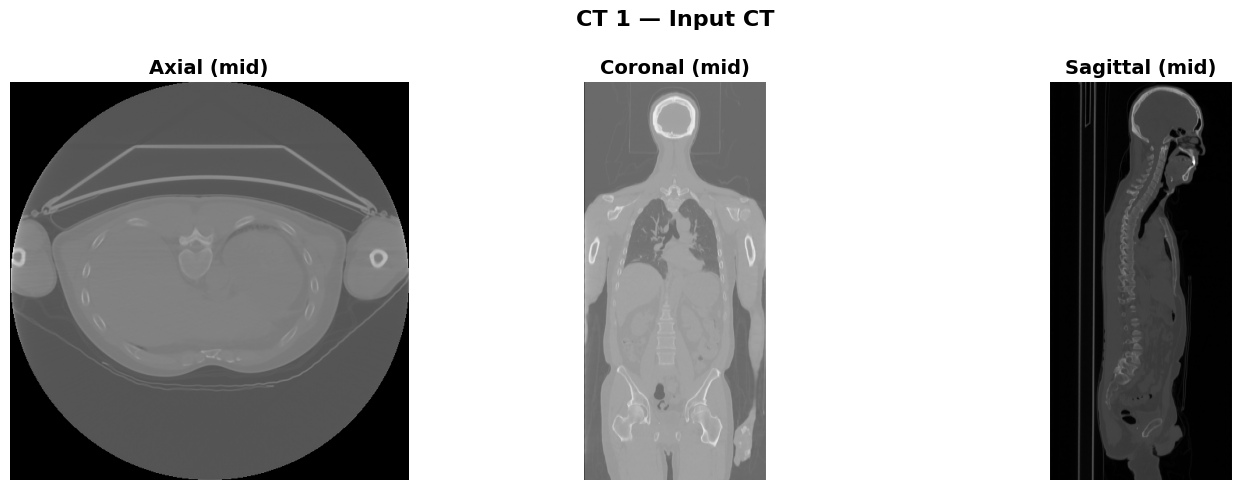

CT 2  shape=(z=335, y=512, x=512)  spacing=(0.98, 0.98, 3.27) mm


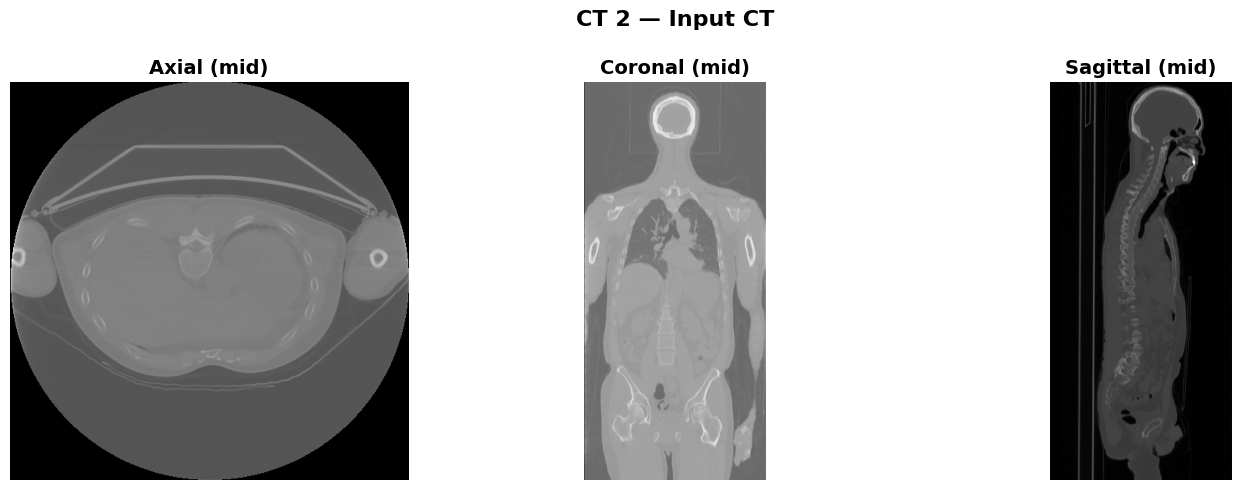

In [75]:
# ── Phase 1a: Input CT ────────────────────────────────────────────────────────
for i, folder in enumerate(OUT_FOLDERS):
    ct_path = os.path.join(folder, 'digital_twin', 'ct.nii.gz')
    if not os.path.exists(ct_path):
        print(f"CT {i+1}: ct.nii.gz not found"); continue

    img = sitk.ReadImage(ct_path)
    arr = sitk.GetArrayFromImage(img)[::-1]   # z,y,x  head-up
    sp  = img.GetSpacing()                    # (x,y,z) mm
    z, y, x = arr.shape
    print(f"CT {i+1}  shape=(z={z}, y={y}, x={x})  spacing=({sp[0]:.2f}, {sp[1]:.2f}, {sp[2]:.2f}) mm")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'CT {i+1} — Input CT')

    axes[0].imshow(arr[z//2, :, :], cmap='gray', aspect=arr_aspect(sp,'axial'))
    axes[0].set_title('Axial (mid)')
    axes[1].imshow(arr[:, y//2, :], cmap='gray', aspect=arr_aspect(sp,'coronal'))
    axes[1].set_title('Coronal (mid)')
    axes[2].imshow(arr[:, :, x//2], cmap='gray', aspect=arr_aspect(sp,'sagittal'))
    axes[2].set_title('Sagittal (mid)')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()

CT 1  seg shape=(335, 512, 512)  labels={1: 'remaining_body', 2: 'kidney', 3: 'liver', 4: 'prostate', 5: 'spleen', 6: 'heart', 7: 'salivary_glands', 8: 'synthetic_lesion'}


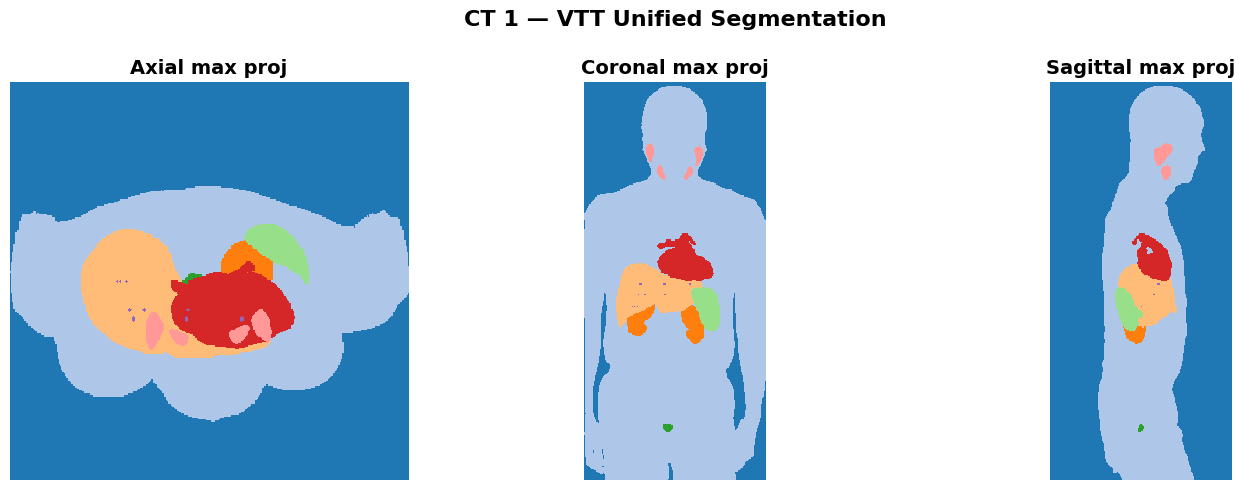

CT 2  seg shape=(335, 512, 512)  labels={1: 'remaining_body', 2: 'kidney'}


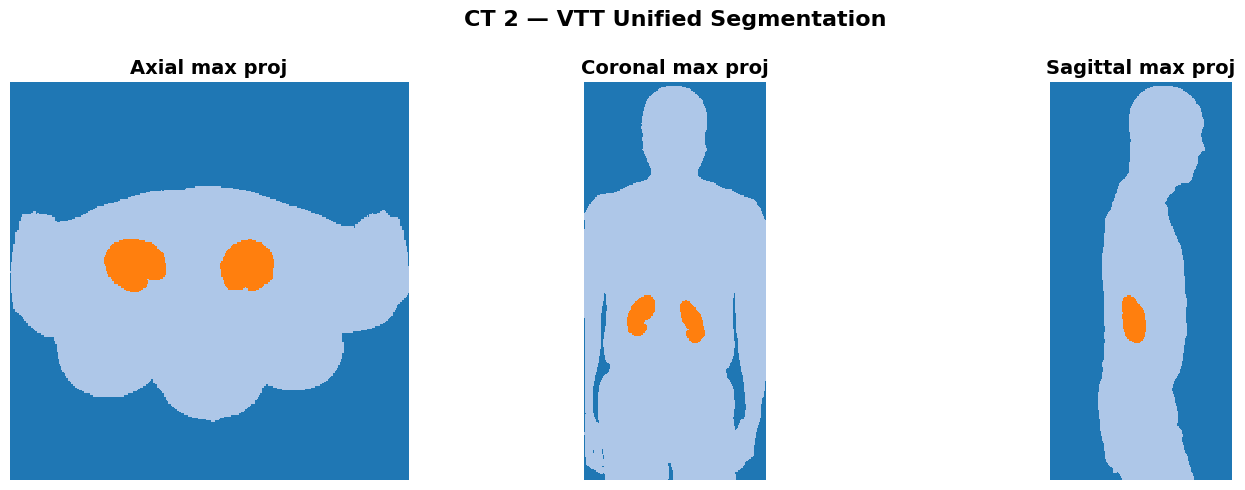

In [76]:
# ── Phase 1b: VTT Segmentation ───────────────────────────────────────────────

# Load VTT label map once
vtt_map_path = os.path.join(OUTPUT_ROOT, 'src', 'data', 'vtt_map.json')
label_to_roi = {}
if os.path.exists(vtt_map_path):
    vtt = load_json(vtt_map_path)
    vtt_pipe = vtt.get('VTT_Pipeline', vtt.get('TDT_Pipeline', {}))
    label_to_roi = {int(k): v.lower() for k, v in vtt_pipe.items()}

for i, folder in enumerate(OUT_FOLDERS):
    seg_path = os.path.join(folder, 'digital_twin', 'digital_twin.nii.gz')
    ct_path  = os.path.join(folder, 'digital_twin', 'ct.nii.gz')
    if not os.path.exists(seg_path):
        print(f"CT {i+1}: digital_twin.nii.gz not found"); continue

    seg_img = sitk.ReadImage(seg_path)
    seg     = sitk.GetArrayFromImage(seg_img)[::-1]   # z,y,x
    sp      = seg_img.GetSpacing()
    labels  = [int(v) for v in np.unique(seg) if v != 0]
    roi_names = [label_to_roi.get(l, str(l)) for l in labels]
    print(f"CT {i+1}  seg shape={seg.shape}  labels={dict(zip(labels, roi_names))}")

    # overlay on CT if available
    ct_arr = sitk.GetArrayFromImage(sitk.ReadImage(ct_path))[::-1] if os.path.exists(ct_path) else None

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'CT {i+1} — VTT Unified Segmentation')

    z, y, x = seg.shape
    views = [
        ('Axial max proj',    np.max(seg, axis=0),  'axial'),
        ('Coronal max proj',  np.max(seg, axis=1),  'coronal'),
        ('Sagittal max proj', np.max(seg, axis=2),  'sagittal'),
    ]
    for ax, (title, proj, vname) in zip(axes, views):
        ax.imshow(proj, cmap='tab20', interpolation='nearest', aspect=arr_aspect(sp, vname),
                  vmin=0, vmax=20)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout(); plt.show()

CT 1  3 lesion(s)  shape=(335, 512, 512)


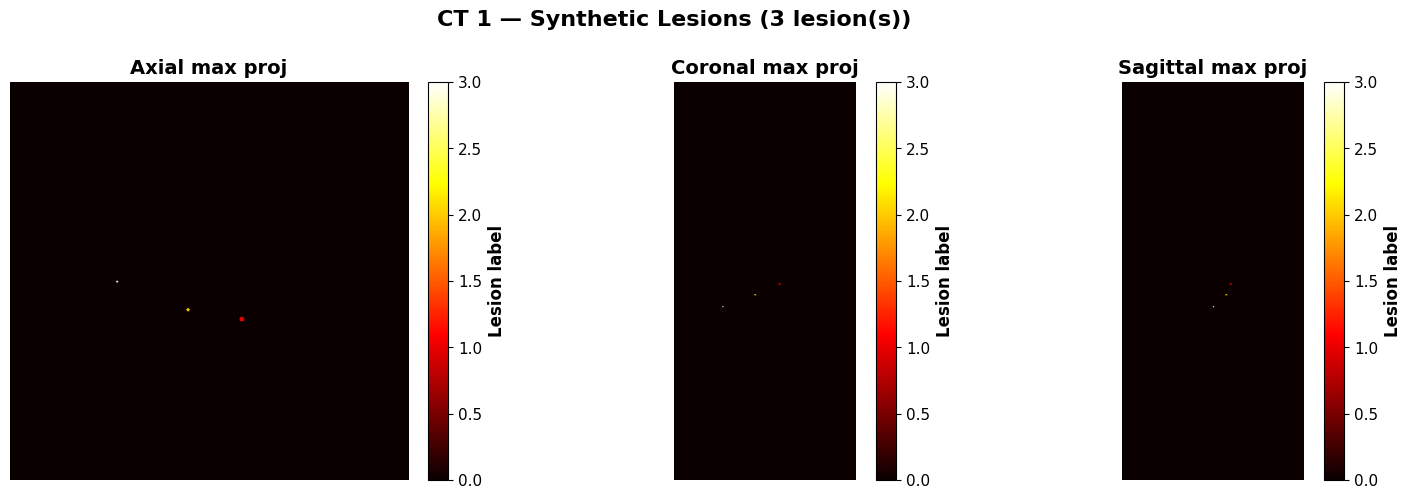

CT 2: no synthetic lesions


In [77]:
# ── Phase 1c: Synthetic Lesions ───────────────────────────────────────────────
for i, folder in enumerate(OUT_FOLDERS):
    # labels file lives directly in synthetic_lesions_stage/, not in work_dir/
    lesion_path = os.path.join(folder, 'digital_twin', 'synthetic_lesions_stage',
                               'synthetic_lesions_all_lesions_labels.nii.gz')
    if not os.path.exists(lesion_path):
        print(f'CT {i+1}: no synthetic lesions'); continue

    img      = sitk.ReadImage(lesion_path)
    arr      = sitk.GetArrayFromImage(img)[::-1]
    sp       = img.GetSpacing()
    n_lesions = int(np.max(arr))
    print(f'CT {i+1}  {n_lesions} lesion(s)  shape={arr.shape}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'CT {i+1} — Synthetic Lesions ({n_lesions} lesion(s))')
    for ax, (title, proj, vn) in zip(axes, [
        ('Axial max proj',    np.max(arr, axis=0), 'axial'),
        ('Coronal max proj',  np.max(arr, axis=1), 'coronal'),
        ('Sagittal max proj', np.max(arr, axis=2), 'sagittal'),
    ]):
        im = ax.imshow(proj, cmap='hot', aspect=arr_aspect(sp, vn))
        ax.set_title(title); ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Lesion label')
    plt.tight_layout(); plt.show()

CT 1: 8 TACs  |  SPECT frame times: ['2.00h', '24.00h', '48.00h']


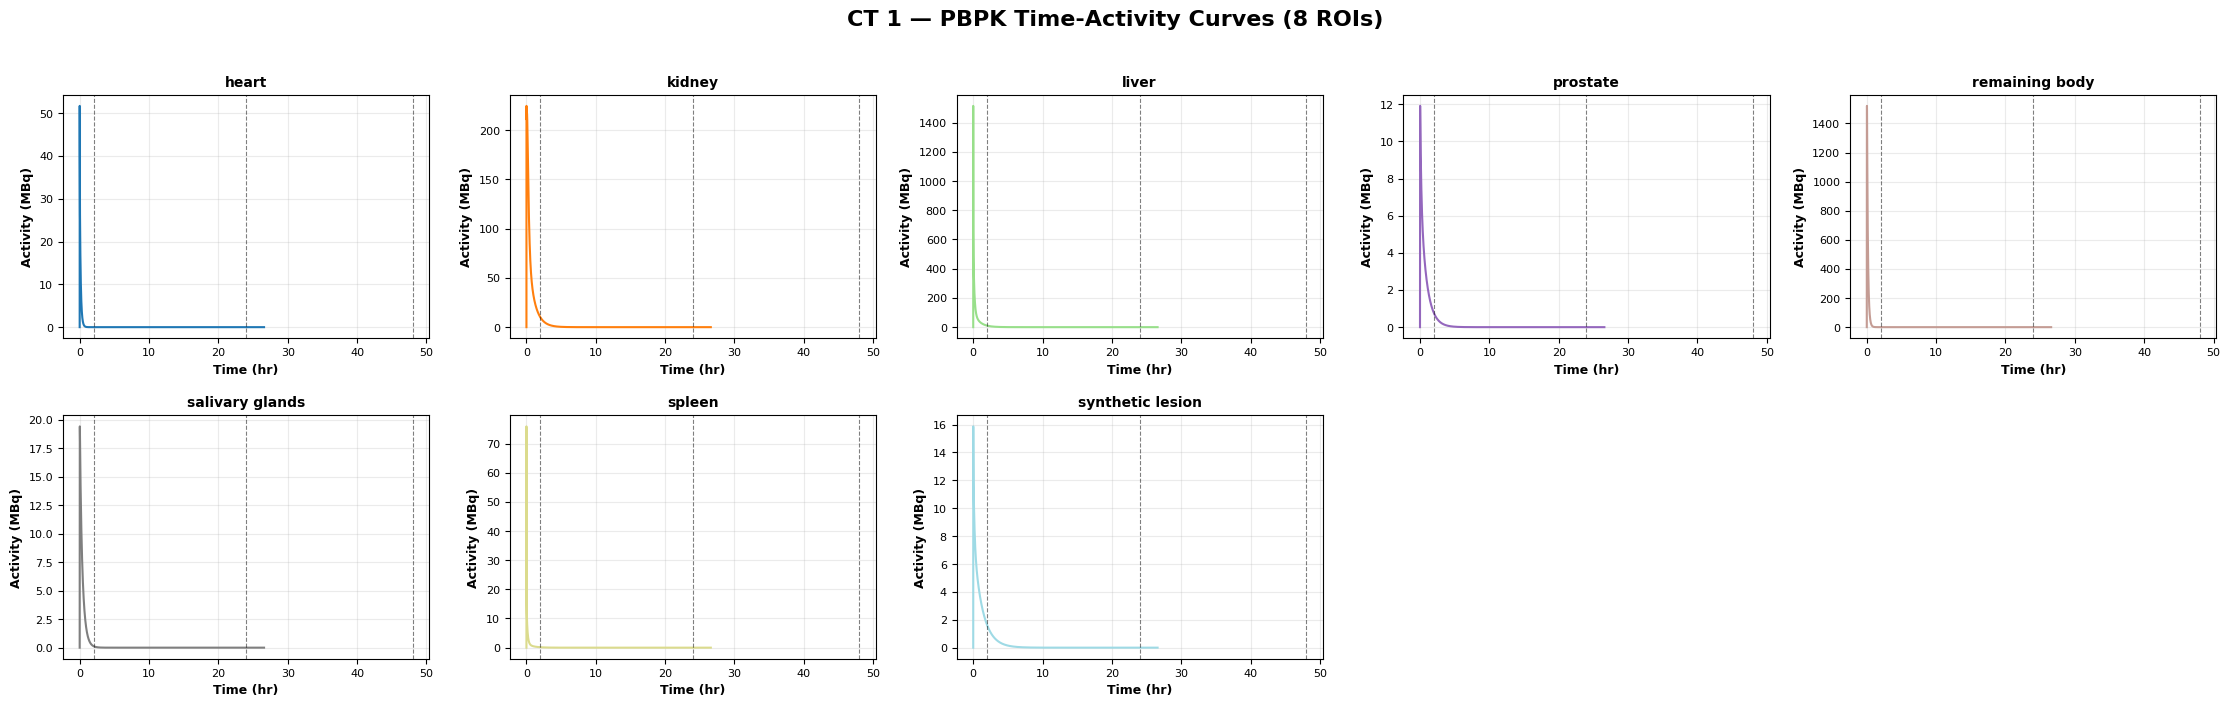

CT 2: 2 TACs  |  SPECT frame times: ['2.00h', '24.00h', '48.00h']


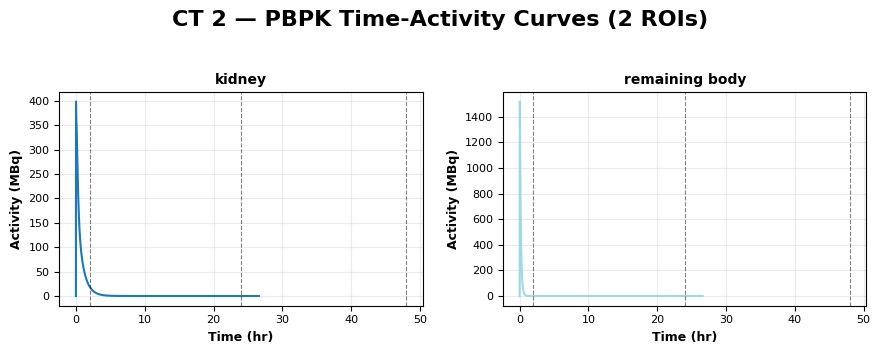

In [78]:
# ── Phase 1d: PBPK TACs ──────────────────────────────────────────────────────
pbpk_store = {}   # {i: {'time_hr': arr, roi: arr_MBq, ...}}

for i, folder in enumerate(OUT_FOLDERS):
    npz_path = os.path.join(folder, 'digital_twin', 'pbpk_tac_stage', 'pbpk_tacs.npz')
    if not os.path.exists(npz_path):
        print(f'CT {i+1}: pbpk_tacs.npz not found'); continue

    data    = np.load(npz_path, allow_pickle=True)
    time_s  = data['time'].astype(float)
    time_hr = time_s / 3600.0
    tac_rois = {k.replace('tac_', ''): data[k].astype(float) for k in data.files if k.startswith('tac_')}
    pbpk_store[i] = {'time_hr': time_hr, **tac_rois}

    # Frame start times come from config (minutes → hours)
    frame_hr = []
    if i in configs:
        ft = configs[i].get('phase_3', {}).get('spect_postprocess_stage', {}).get('FrameStartTimes', [])
        frame_hr = [t / 60.0 for t in ft]

    plot_rois = sorted(tac_rois.keys())   # ALL TACs, including remaining_body
    ncols = min(len(plot_rois), 5)
    nrows = max(1, (len(plot_rois) + ncols - 1) // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows), squeeze=False)
    fig.suptitle(f'CT {i+1} — PBPK Time-Activity Curves ({len(plot_rois)} ROIs)', y=1.01)
    colors = plt.cm.tab20(np.linspace(0, 1, len(plot_rois)))

    for j, (roi, col) in enumerate(zip(plot_rois, colors)):
        ax = axes[j // ncols][j % ncols]
        ax.plot(time_hr, tac_rois[roi], lw=1.5, color=col)
        for ft in frame_hr:
            ax.axvline(ft, color='k', lw=0.8, ls='--', alpha=0.5)
        ax.set_title(roi.replace('_', ' '), fontsize=10)
        ax.set_xlabel('Time (hr)', fontsize=9)
        ax.set_ylabel('Activity (MBq)', fontsize=9)
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=8)

    for j in range(len(plot_rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    if frame_hr:
        print(f'CT {i+1}: {len(plot_rois)} TACs  |  SPECT frame times: {[f"{t:.2f}h" for t in frame_hr]}')
    else:
        print(f'CT {i+1}: {len(plot_rois)} TACs')
    plt.tight_layout(); plt.show()

---
## 4 — Phase 2: Simulations

CT 1  prefix=simind  ROIs=['remaining_body', 'kidney']
  scale_factor=1.0000  spacing_cm=[0.327, 0.098, 0.098]  shape=[335, 512, 512]
  pixel_width=0.098 cm  slice_width=0.327 cm


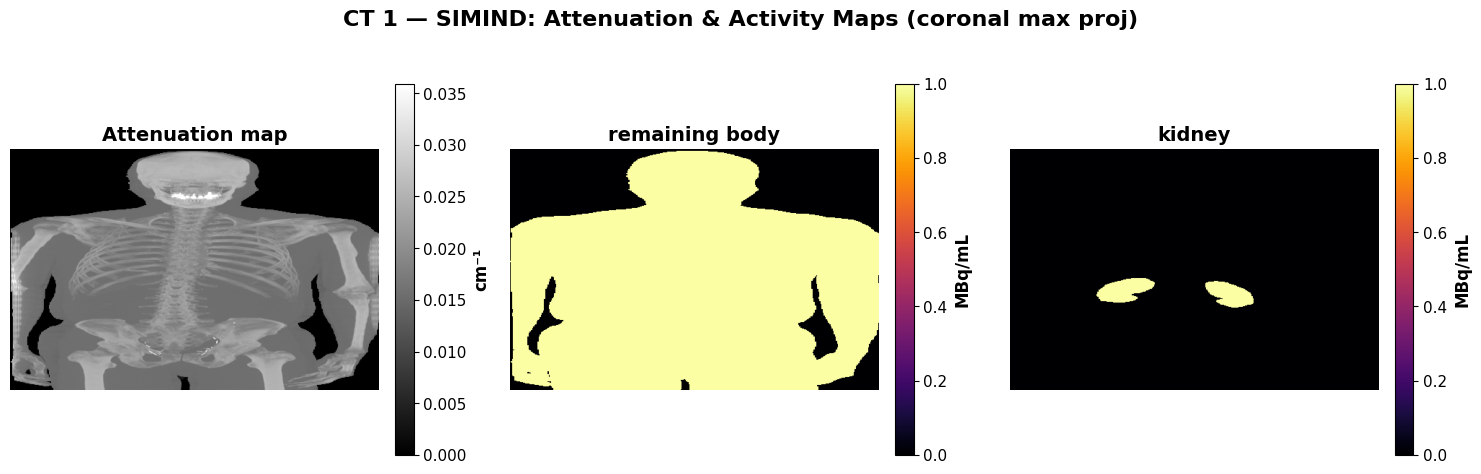

CT 2  prefix=simind  ROIs=['remaining_body', 'kidney']
  scale_factor=1.0000  spacing_cm=[0.4, 0.2, 0.2]  shape=[274, 250, 250]
  pixel_width=0.200 cm  slice_width=0.400 cm


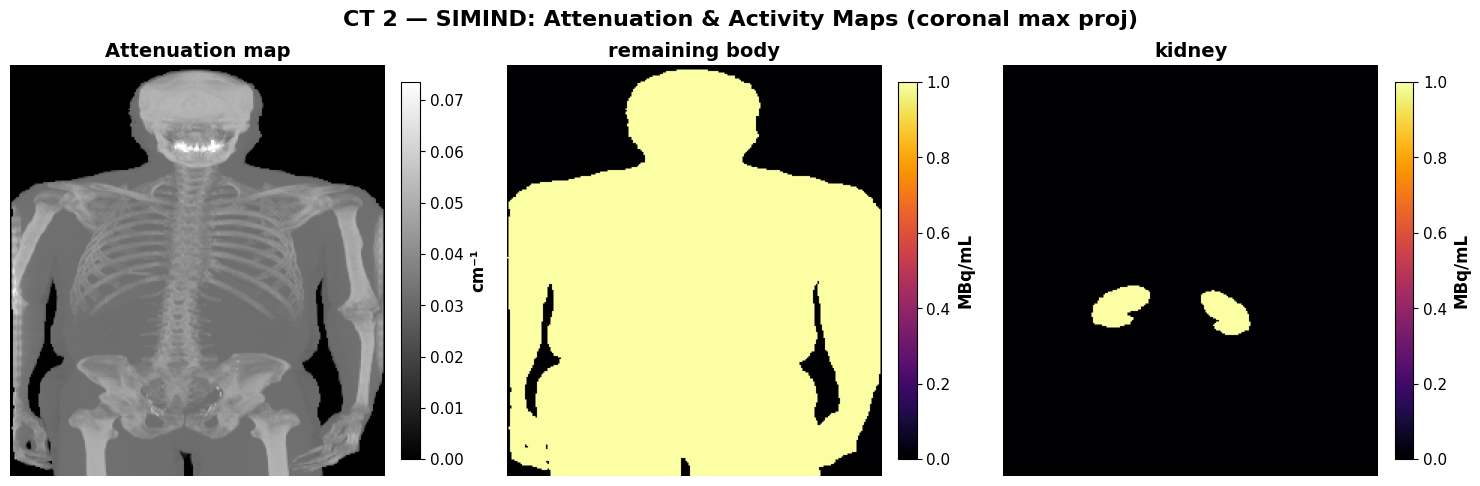

In [79]:
# ── Phase 2a: SIMIND — Attenuation map + Activity maps ────────────────────────
simind_meta_store = {}

for i, folder in enumerate(OUT_FOLDERS):
    # metadata lives in pipeline_metadata/, not inside simulations/
    meta_path = os.path.join(folder, 'pipeline_metadata', 'simind_simulation_stage.json')
    if not os.path.exists(meta_path):
        print(f'CT {i+1}: SIMIND metadata not found'); continue

    m = load_json(meta_path)
    simind_meta_store[i] = m

    prefix    = m.get('file_prefix', 'simind')
    roi_list  = m.get('roi_list', [])
    scale     = m.get('scale_factor', 1.0)
    geom      = m.get('geometry', {})
    prep_dir  = m.get('preprocess_dir', '')
    work_dir  = m.get('work_dir', '')
    spacing   = m.get('arr_px_spacing_cm', [0, 0, 0])
    shape_new = m.get('arr_shape_new', [0, 0, 0])
    xy_dim    = int(shape_new[1]) if len(shape_new) > 1 else 128

    print(f"CT {i+1}  prefix={prefix}  ROIs={roi_list}")
    print(f"  scale_factor={scale:.4f}  spacing_cm={[round(s, 3) for s in spacing]}  shape={shape_new}")
    print(f"  pixel_width={geom.get('input_pixel_width', 0):.3f} cm  "
          f"slice_width={geom.get('input_slice_width', 0):.3f} cm")

    # ATN map (in preprocess dir or work dir)
    atn_flat = None
    for search_dir in [prep_dir, work_dir]:
        atn_p = os.path.join(search_dir, f'{prefix}_atn_av.bin')
        if os.path.exists(atn_p):
            atn_flat = np.fromfile(atn_p, dtype=np.float32)
            break

    # Activity maps — all ROIs in roi_list
    act_maps = {}
    for roi in roi_list:
        p = os.path.join(prep_dir, f'{prefix}_{roi}_act_av.bin')
        if os.path.exists(p):
            flat = np.fromfile(p, dtype=np.float32)
            z_sz = flat.size // (xy_dim * xy_dim) if xy_dim > 0 else 0
            if z_sz > 0 and z_sz * xy_dim * xy_dim == flat.size:
                act_maps[roi] = flat.reshape(z_sz, xy_dim, xy_dim)[::-1]

    n_plots = (1 if atn_flat is not None else 0) + len(act_maps)
    if n_plots == 0:
        print('  No binary maps found'); continue

    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1: axes = [axes]
    fig.suptitle(f'CT {i+1} — SIMIND: Attenuation & Activity Maps (coronal max proj)')
    idx = 0

    if atn_flat is not None:
        z_sz = atn_flat.size // (xy_dim * xy_dim)
        if z_sz > 0 and z_sz * xy_dim * xy_dim == atn_flat.size:
            atn = atn_flat.reshape(z_sz, xy_dim, xy_dim)[::-1]
            im = axes[idx].imshow(np.max(atn, axis=1), cmap='gray', aspect='equal')
            axes[idx].set_title('Attenuation map'); axes[idx].axis('off')
            plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label='cm⁻¹')
            idx += 1

    for roi, arr in act_maps.items():
        im = axes[idx].imshow(np.max(arr, axis=1), cmap='inferno', aspect='equal')
        axes[idx].set_title(roi.replace('_', ' ')); axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label='MBq/mL')
        idx += 1

    plt.tight_layout(); plt.show()

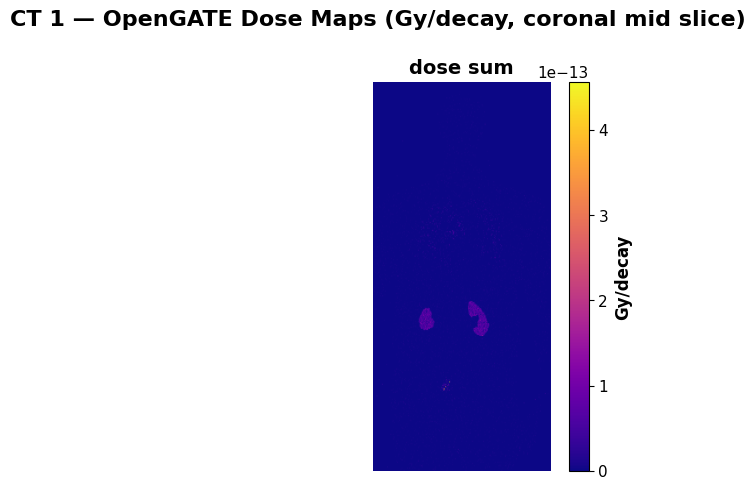

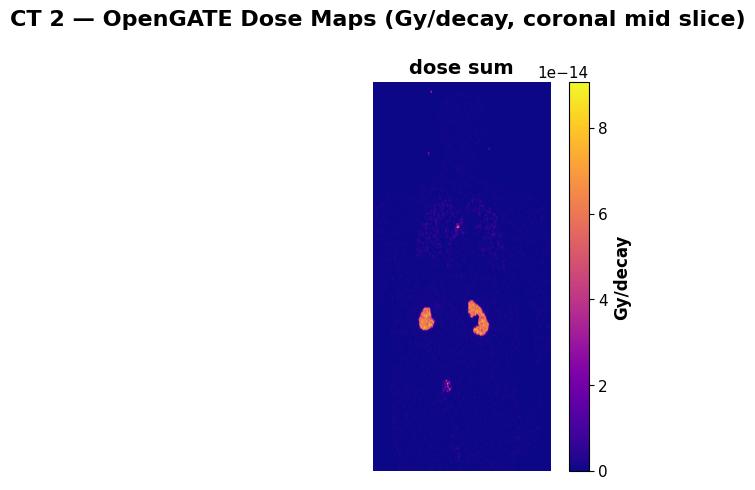

In [80]:
# ── Phase 2b: OpenGATE Dose Maps ─────────────────────────────────────────────
for i, folder in enumerate(OUT_FOLDERS):
    og_cfg  = configs.get(i, {}).get('phase_2', {}).get('opengate_stage', {})
    prefix  = og_cfg.get('file_prefix', 'opengate_simulation')
    og_dir  = os.path.join(folder, 'simulations', og_cfg.get('sub_dir_name', 'opengate_simulation'))
    og_work = os.path.join(og_dir, 'work_dir')

    # Per-ROI dose NIfTIs: new runs → stage dir; old runs → work_dir
    dose_roi_files = list_files(og_dir, '_dose_.nii.gz') or []
    # more robust: any file matching prefix_dose_<roi>.nii.gz
    tag = prefix + '_dose_'
    dose_roi_files = [f for f in list_files(og_dir, '.nii.gz') if os.path.basename(f).startswith(tag)]
    if not dose_roi_files:
        dose_roi_files = [f for f in list_files(og_work, '.nii.gz') if os.path.basename(f).startswith(tag)]

    # Dose sum: new runs → simulations/, old runs → opengate_simulation/
    dose_sum_path = None
    for candidate in [
        os.path.join(folder, 'simulations', prefix + '_dose_sum.nii.gz'),
        os.path.join(og_dir, prefix + '_dose_sum.nii.gz'),
    ]:
        if os.path.exists(candidate):
            dose_sum_path = candidate
            break

    # Build (label, path) list — exclude the dose_sum from per-ROI list
    all_dose = []
    for p in dose_roi_files:
        s = stem(p)
        if s.endswith('_dose_sum'):
            continue
        roi_label = s[len(tag):] if s.startswith(tag) else s
        all_dose.append((roi_label, p))
    if dose_sum_path:
        all_dose.append(('dose sum', dose_sum_path))

    if not all_dose:
        print(f'CT {i+1}: no OpenGATE dose maps found (--dosimetry not run)'); continue

    ncols = min(len(all_dose), 4)
    nrows = max(1, (len(all_dose) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)
    fig.suptitle(f'CT {i+1} — OpenGATE Dose Maps (Gy/decay, coronal mid slice)')

    for j, (label, path) in enumerate(all_dose):
        ax  = axes[j // ncols][j % ncols]
        img = sitk.ReadImage(path)
        arr = sitk.GetArrayFromImage(img)[::-1]
        sp  = img.GetSpacing()
        z, y, x = arr.shape
        im  = ax.imshow(arr[:, y // 2, :], cmap='plasma', aspect=arr_aspect(sp, 'coronal'))
        ax.set_title(label.replace('_', ' ')); ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Gy/decay')

    for j in range(len(all_dose), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    plt.tight_layout(); plt.show()

---
## 5 — Phase 3: Post-Processing

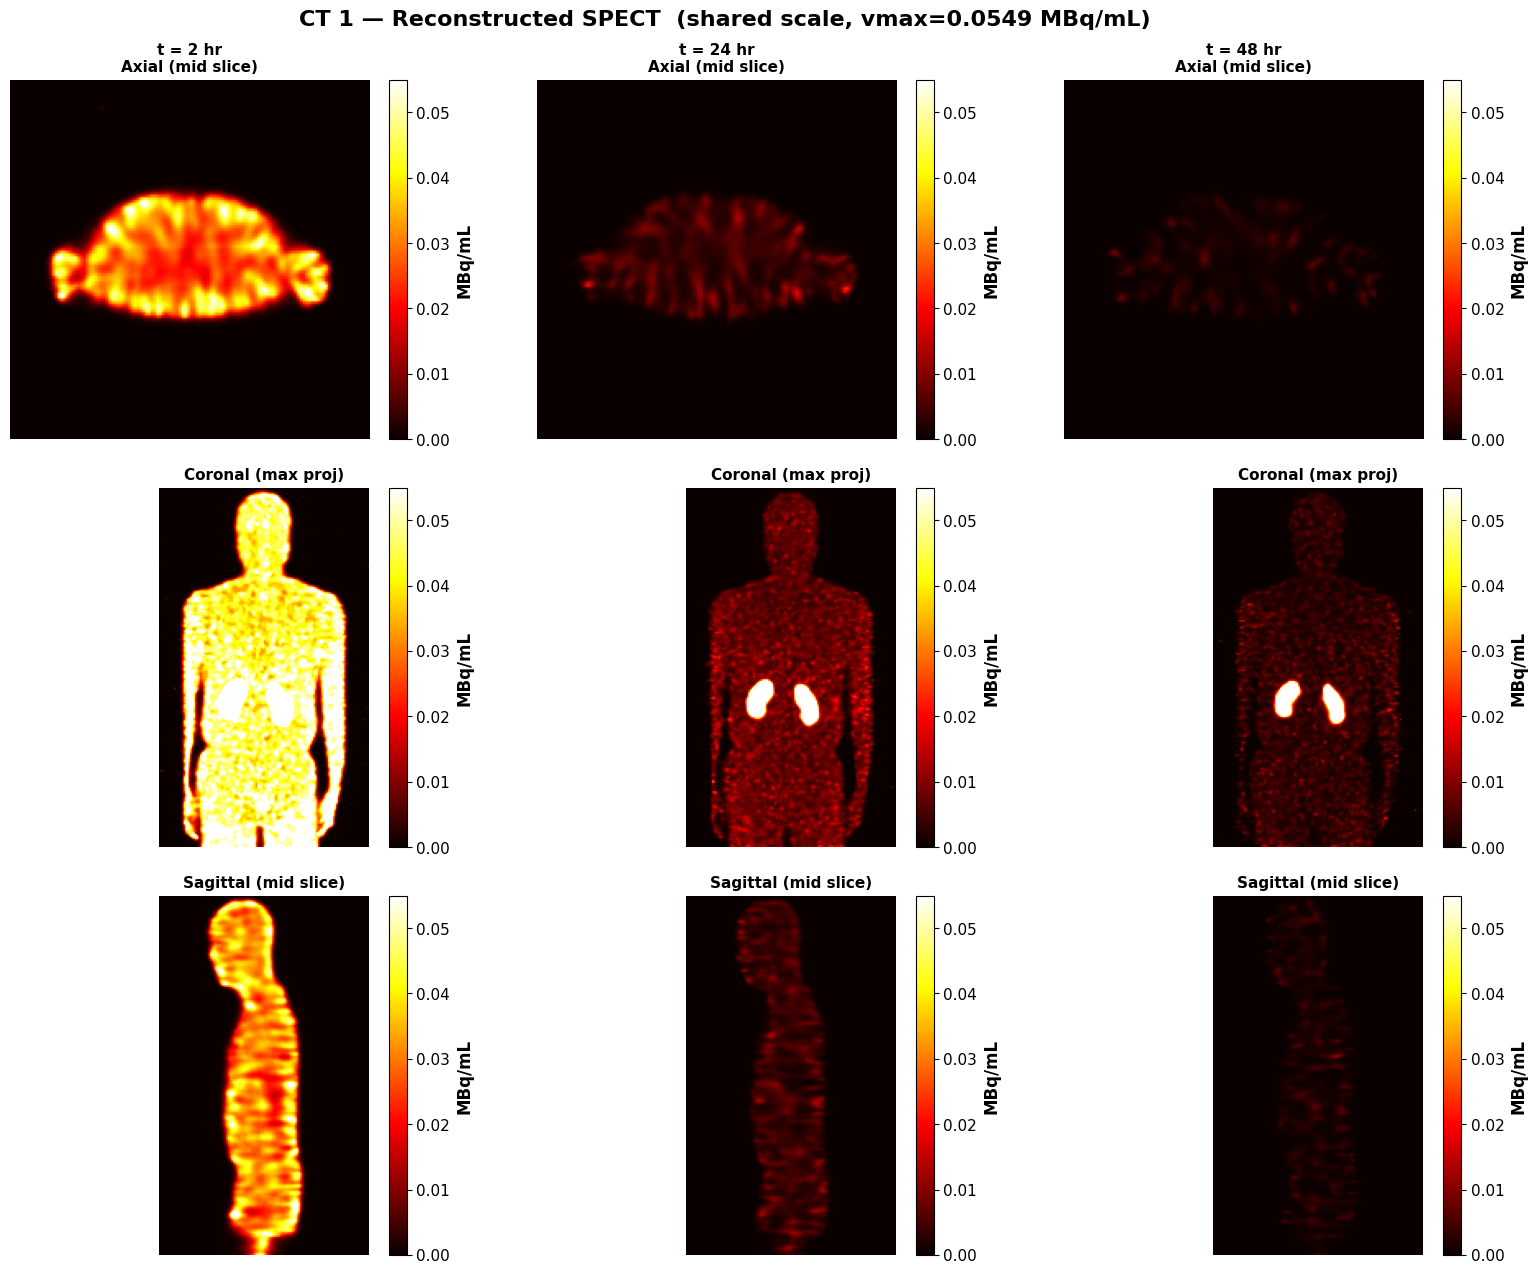

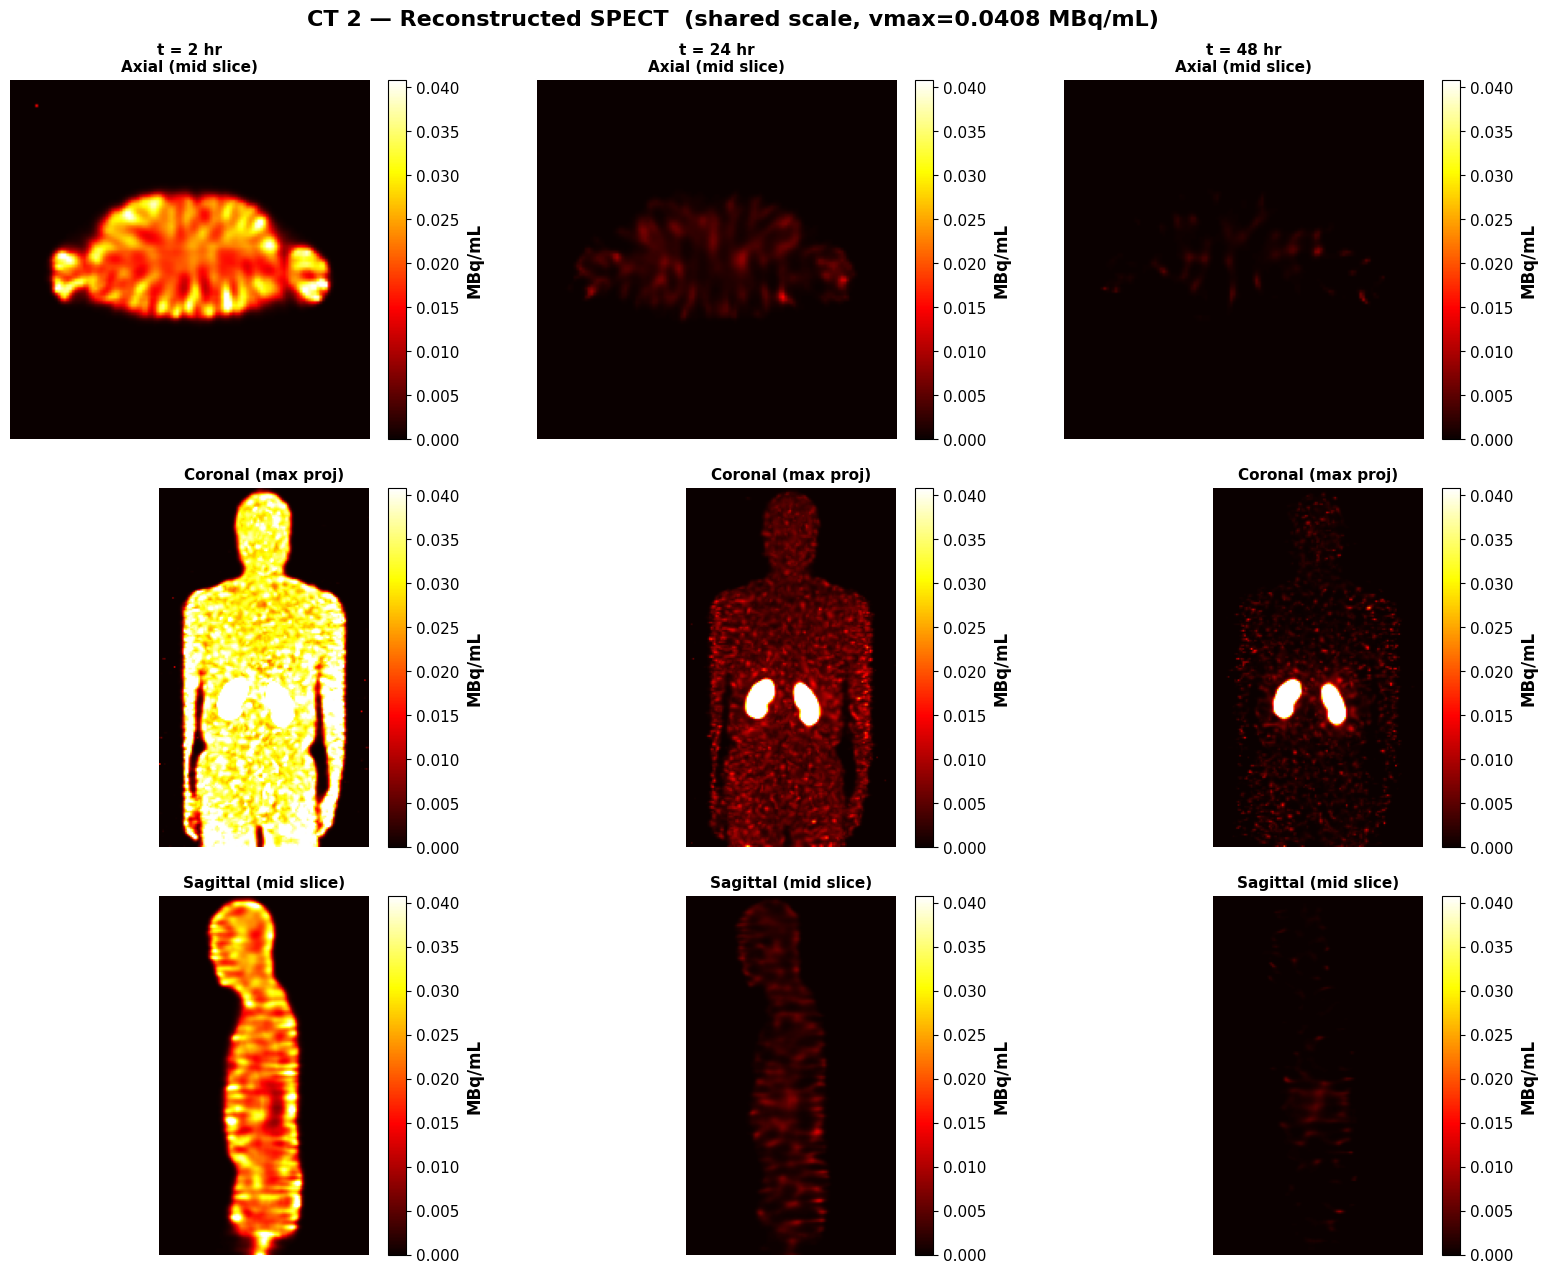

In [81]:
# ── Phase 3a: Reconstructed SPECT ────────────────────────────────────────────
recon_paths_store = {}

for i, folder in enumerate(OUT_FOLDERS):
    pp_dir = os.path.join(folder, 'post_processing')
    recons = [
        os.path.join(pp_dir, f) for f in sorted(os.listdir(pp_dir))
        if f.startswith('reconstructed_SPECT_') and f.endswith('.nii.gz')
    ] if os.path.isdir(pp_dir) else []

    if not recons:
        print(f'CT {i+1}: no reconstructed SPECT (--spect --postprocess not run)'); continue

    frame_map = {}
    for p in recons:
        fname = os.path.basename(p)
        label = fname.replace('reconstructed_SPECT_', '').replace('.nii.gz', '')
        frame_map[label] = p
    recon_paths_store[i] = frame_map

    arrs = {}
    vmax = 0.0
    for label in sorted(frame_map, key=lambda k: float(k)):
        img = sitk.ReadImage(frame_map[label])
        a   = sitk.GetArrayFromImage(img)[::-1]
        sp  = img.GetSpacing()
        arrs[label] = (a, sp)
        pos = a[a > 0]
        if len(pos):
            vmax = max(vmax, float(np.percentile(pos, 99.5)))

    frame_labels = sorted(arrs.keys(), key=lambda k: float(k))
    ncols = len(frame_labels)

    # 3 rows: axial mid / coronal max proj / sagittal mid — columns = timepoints
    fig, axes = plt.subplots(3, ncols, figsize=(5.5 * ncols, 13))
    if ncols == 1:
        axes = axes.reshape(3, 1)
    fig.suptitle(f'CT {i+1} — Reconstructed SPECT  (shared scale, vmax={vmax:.3g} MBq/mL)')

    row_labels = ['Axial (mid slice)', 'Coronal (max proj)', 'Sagittal (mid slice)']
    for j, label in enumerate(frame_labels):
        arr, sp = arrs[label]
        z, y, x = arr.shape
        views = [
            (arr[z//2, :, :],     arr_aspect(sp, 'axial')),
            (np.max(arr, axis=1), arr_aspect(sp, 'coronal')),
            (arr[:, :, x//2],     arr_aspect(sp, 'sagittal')),
        ]
        for row, (sl, asp) in enumerate(views):
            ax = axes[row][j]
            im = ax.imshow(sl, cmap='hot', aspect=asp, vmin=0, vmax=vmax)
            title = f't = {label} hr\n{row_labels[row]}' if row == 0 else row_labels[row]
            ax.set_title(title, fontsize=11); ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='MBq/mL')

    plt.tight_layout(); plt.show()

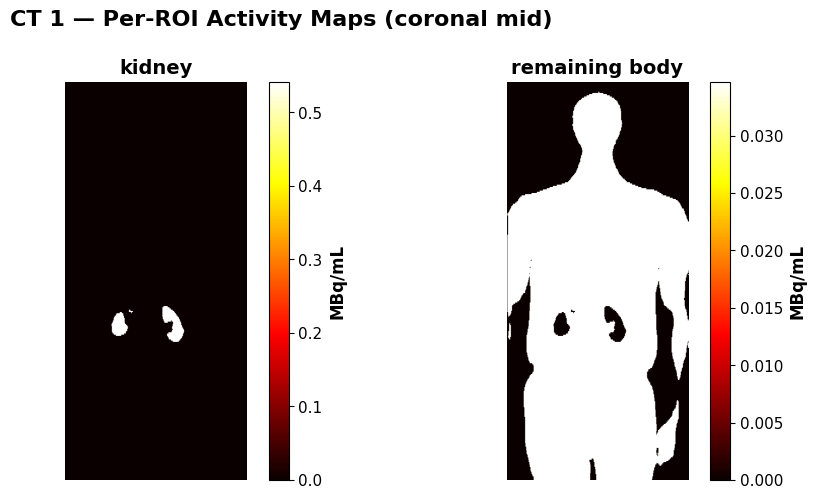

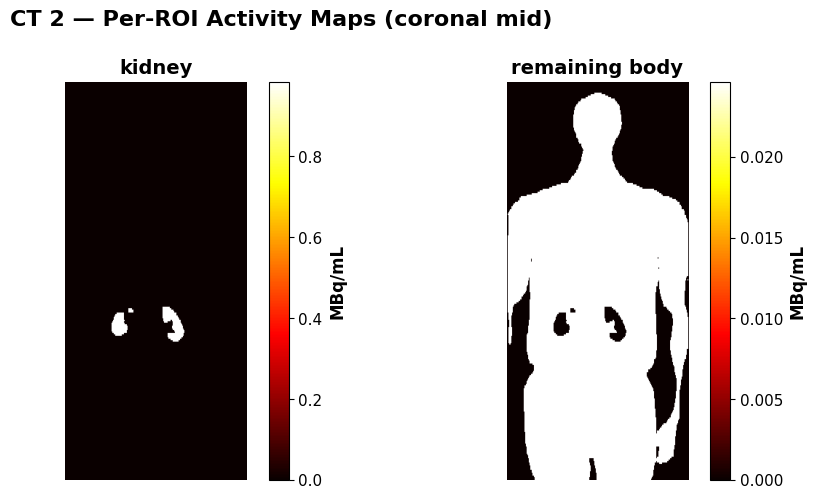

In [82]:
# ── Phase 3b: Per-ROI Activity Maps ──────────────────────────────────────────
for i, folder in enumerate(OUT_FOLDERS):
    work_dir = os.path.join(folder, 'post_processing', 'spect_postprocess', 'work_dir')
    act_files = list_files(work_dir, '_act_av.nii.gz')
    if not act_files:
        print(f'CT {i+1}: no per-ROI activity maps'); continue

    sp_prefix = configs.get(i, {}).get('phase_3', {}).get('spect_postprocess_stage', {}).get('file_prefix', 'spect_postprocess')
    labels = []
    for p in act_files:
        s = stem(p).replace('_act_av', '')
        roi = s[len(sp_prefix)+1:] if s.startswith(sp_prefix + '_') else s
        labels.append(roi)

    ncols = min(len(act_files), 4)
    nrows = max(1, (len(act_files) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)
    fig.suptitle(f'CT {i+1} — Per-ROI Activity Maps (coronal mid)')

    for j, (path, label) in enumerate(zip(act_files, labels)):
        ax  = axes[j // ncols][j % ncols]
        img = sitk.ReadImage(path)
        arr = sitk.GetArrayFromImage(img)[::-1]
        sp  = img.GetSpacing()
        z, y, x = arr.shape
        im = ax.imshow(arr[:, y//2, :], cmap='hot', aspect=arr_aspect(sp, 'coronal'))
        ax.set_title(label.replace('_', ' ')); ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='MBq/mL')

    for j in range(len(act_files), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    plt.tight_layout(); plt.show()

CT 1  dose shape=(335, 512, 512)  spacing=(0.98, 0.98, 3.27) mm  max=109 Gy


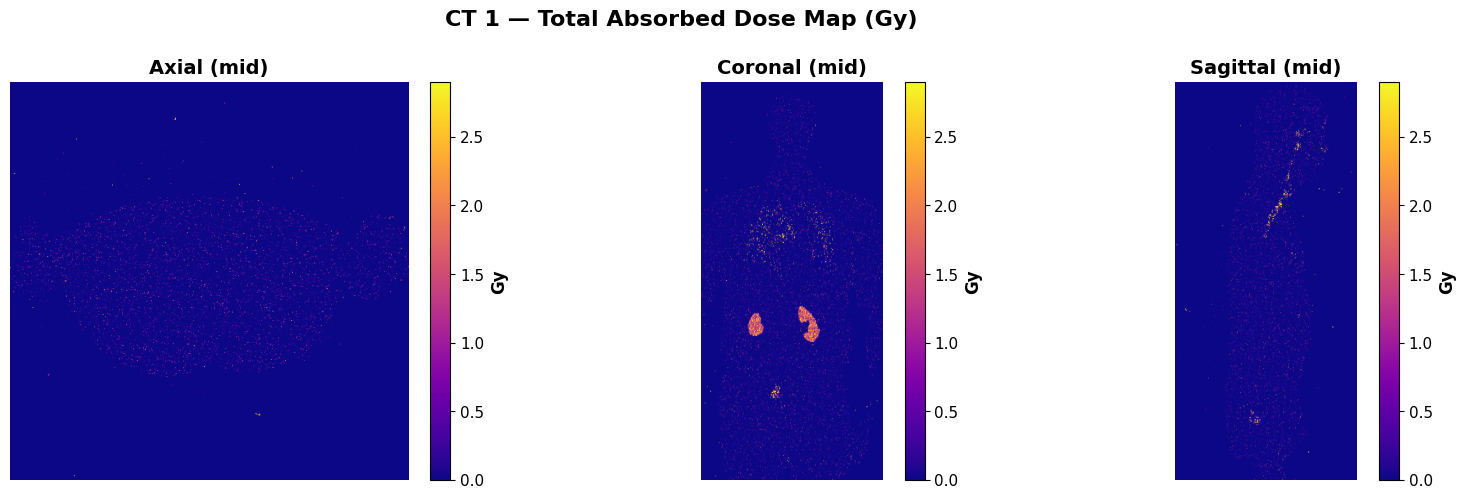

CT 2  dose shape=(335, 512, 512)  spacing=(0.98, 0.98, 3.27) mm  max=11.47 Gy


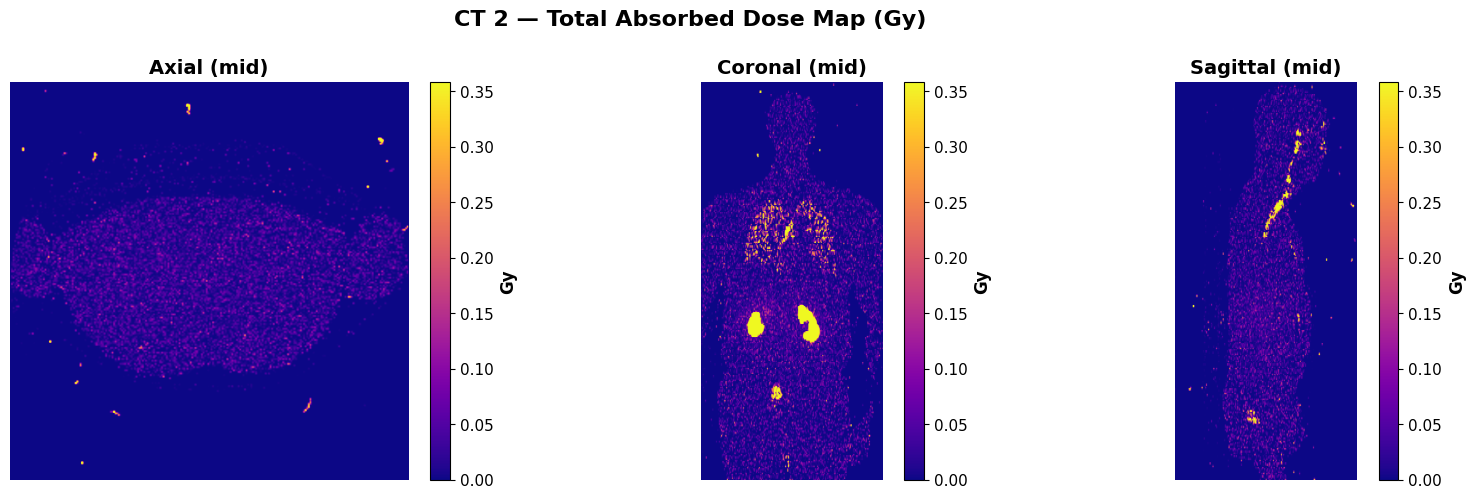

In [83]:
# ── Phase 3c: Total Dose Map ──────────────────────────────────────────────────
for i, folder in enumerate(OUT_FOLDERS):
    dose_path = os.path.join(folder, 'post_processing', 'dosemap_postprocess_total_dose.nii.gz')
    if not os.path.exists(dose_path):
        print(f'CT {i+1}: total dose map not found (--dosimetry --postprocess not run)'); continue

    img = sitk.ReadImage(dose_path)
    arr = sitk.GetArrayFromImage(img)[::-1]
    sp  = img.GetSpacing()
    z, y, x = arr.shape
    print(f'CT {i+1}  dose shape={arr.shape}  spacing={tuple(round(s,2) for s in sp)} mm  '
          f'max={np.max(arr):.4g} Gy')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'CT {i+1} — Total Absorbed Dose Map (Gy)')
    vm = np.percentile(arr[arr > 0], 99) if np.any(arr > 0) else arr.max()

    for ax, (title, sl, vn) in zip(axes, [
        ('Axial (mid)',    arr[z//2, :, :],  'axial'),
        ('Coronal (mid)',  arr[:, y//2, :],  'coronal'),
        ('Sagittal (mid)', arr[:, :, x//2], 'sagittal'),
    ]):
        im = ax.imshow(sl, cmap='plasma', aspect=arr_aspect(sp, vn), vmin=0, vmax=vm)
        ax.set_title(title); ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Gy')
    plt.tight_layout(); plt.show()

---
## 6 — SPECT Comparison Study

### Setup — Register segmentation to SPECT recon space & build ROI masks

The VTT unified segmentation (`digital_twin.nii.gz`) is in mm at native CT resolution. The SPECT recon images are in cm (SIMIND/PyTomography convention, ~0.5 cm/pixel). We center-align both images then resample the segmentation onto the SPECT grid with nearest-neighbour interpolation.

In [84]:
def physical_center(img):
    size = np.array(img.GetSize(), dtype=float)
    sp   = np.array(img.GetSpacing(), dtype=float)
    orig = np.array(img.GetOrigin(), dtype=float)
    D    = np.array(img.GetDirection(), dtype=float).reshape(3, 3)
    return orig + D @ ((size - 1.0) / 2.0 * sp)

def set_center(img, target):
    img  = sitk.Image(img)
    size = np.array(img.GetSize(), dtype=float)
    sp   = np.array(img.GetSpacing(), dtype=float)
    D    = np.array(img.GetDirection(), dtype=float).reshape(3, 3)
    img.SetOrigin((target - D @ ((size - 1.0) / 2.0 * sp)).tolist())
    return img

def scale_img(img, factor):
    """Scale spacing and origin by factor (e.g. 0.1 for mm→cm)."""
    img = sitk.Image(img)
    img.SetSpacing((np.array(img.GetSpacing()) * factor).tolist())
    img.SetOrigin( (np.array(img.GetOrigin())  * factor).tolist())
    return img

def resample_nn(moving, reference):
    rs = sitk.ResampleImageFilter()
    rs.SetReferenceImage(reference)
    rs.SetInterpolator(sitk.sitkNearestNeighbor)
    rs.SetDefaultPixelValue(0)
    return rs.Execute(moving)


masks_recon   = {}   # {i: {roi_lower: bool mask (z,y,x)}}
recon_imgs_sitk = {} # {i: {label: sitk.Image}}
recon_vox_ml  = {}   # {i: float}
recon_arr_ref = {}   # {i: (arr_zyx, sp)}  — latest frame, for overlay plots

for i, folder in enumerate(OUT_FOLDERS):
    if i not in recon_paths_store:
        print(f'CT {i+1}: no recon paths — skipping comparison'); continue

    seg_path = os.path.join(folder, 'digital_twin', 'digital_twin.nii.gz')
    if not os.path.exists(seg_path):
        print(f'CT {i+1}: digital_twin.nii.gz not found'); continue

    frame_map = recon_paths_store[i]
    ref_label = sorted(frame_map.keys(), key=lambda k: float(k))[-1]
    ref_img   = sitk.ReadImage(frame_map[ref_label])
    sp_recon  = np.array(ref_img.GetSpacing())

    recon_imgs_sitk[i] = {lbl: sitk.ReadImage(p) for lbl, p in frame_map.items()}
    recon_vox_ml[i]    = float(np.prod(sp_recon))  / 1000.0  # mm³ → mL  (or cm³ → mL if in cm)

    recon_arr_ref[i] = (sitk.GetArrayFromImage(ref_img)[::-1], sp_recon)

    seg_img = sitk.ReadImage(seg_path)
    sp_seg  = np.array(seg_img.GetSpacing())

    # if seg is in mm and recon is in cm, scale seg → cm
    if sp_seg[0] / sp_recon[0] > 5:
        seg_img = scale_img(seg_img, 0.1)

    # center-align seg to recon
    seg_centered = set_center(seg_img, physical_center(ref_img))
    seg_in_recon = resample_nn(seg_centered, ref_img)
    seg_arr      = sitk.GetArrayFromImage(seg_in_recon).astype(np.int16)

    masks_recon[i] = {}
    for lbl in np.unique(seg_arr):
        if lbl == 0: continue
        roi_name = label_to_roi.get(int(lbl), f'label_{lbl}')
        masks_recon[i][roi_name] = (seg_arr == lbl)

    print(f'CT {i+1}: masks built — {list(masks_recon[i].keys())}')
    print(f'  Recon spacing={sp_recon.round(3)}  vox_vol={recon_vox_ml[i]:.4f} mL/vox')

CT 1: masks built — ['remaining_body', 'kidney', 'liver', 'heart']
  Recon spacing=[0.5 0.5 0.5]  vox_vol=0.0001 mL/vox
CT 2: masks built — ['remaining_body', 'kidney']
  Recon spacing=[0.5 0.5 0.5]  vox_vol=0.0001 mL/vox


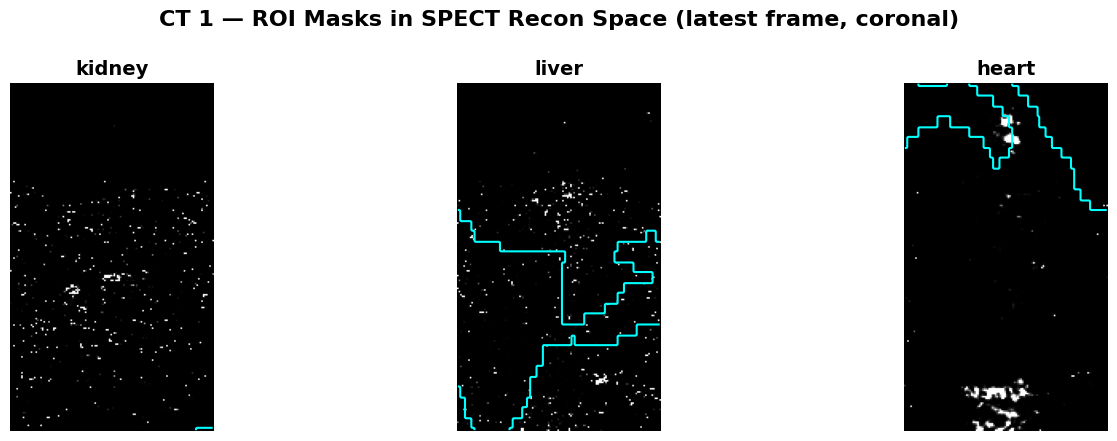

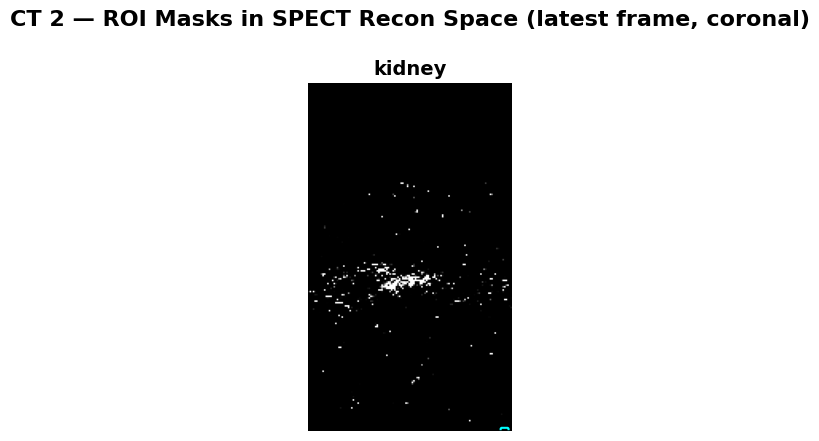

In [85]:
# ── Mask overlay — sanity check (all patients) ────────────────────────────────
for i in masks_recon:
    arr_ref, sp = recon_arr_ref[i]
    rois = [r for r in masks_recon[i] if r not in ('background', 'remaining_body')]
    if not rois: continue

    ncols = min(len(rois), 5)
    nrows = max(1, (len(rois) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)
    fig.suptitle(f'CT {i+1} — ROI Masks in SPECT Recon Space (latest frame, coronal)')

    for j, roi in enumerate(rois):
        ax   = axes[j // ncols][j % ncols]
        mask = masks_recon[i][roi][::-1]   # flip back so head is up
        pts  = np.argwhere(mask)
        if len(pts) == 0: ax.set_visible(False); continue
        y_sl = int(np.round(pts[:, 1].mean()))

        sl_recon = arr_ref[:, y_sl, :]
        sl_mask  = mask[:, y_sl, :]
        vmax_r   = np.percentile(sl_recon[np.isfinite(sl_recon)], 99)

        ax.imshow(sl_recon, cmap='gray', aspect=arr_aspect(sp,'coronal'), vmin=0, vmax=vmax_r)
        ax.contour(sl_mask.astype(np.uint8), levels=[0.5], colors='cyan', linewidths=1.5)
        ax.set_title(roi.replace('_',' ')); ax.axis('off')

    for j in range(len(rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    plt.tight_layout(); plt.show()

In [86]:
# ── Extract SPECT TACs ────────────────────────────────────────────────────────
def roi_stats(arr_zyx, mask_zyx, vox_vol_ml):
    n = int(mask_zyx.sum())
    if n == 0: return 0.0, 0.0, 0
    total = float(np.sum(arr_zyx[mask_zyx]))
    return total / n, total * vox_vol_ml, n

spect_tacs = {}   # {i: {roi: {'frame_hr':[], 'sum_mbq':[], 'mean_mbq_ml':[]}}}

for i in masks_recon:
    frame_map = recon_imgs_sitk[i]
    frame_hrs = sorted(frame_map.keys(), key=lambda k: float(k))
    rois      = [r for r in masks_recon[i] if r not in ('background',)]
    vox_ml    = recon_vox_ml[i]

    spect_tacs[i] = {roi: {'frame_hr': [], 'sum_mbq': [], 'mean_mbq_ml': []} for roi in rois}

    for lbl in frame_hrs:
        arr = sitk.GetArrayFromImage(frame_map[lbl]).astype(np.float32)  # z,y,x
        for roi in rois:
            mask = masks_recon[i][roi]
            if arr.shape != mask.shape: continue
            mean_c, total, _ = roi_stats(arr, mask, vox_ml)
            spect_tacs[i][roi]['frame_hr'].append(float(lbl))
            spect_tacs[i][roi]['sum_mbq'].append(total)
            spect_tacs[i][roi]['mean_mbq_ml'].append(mean_c)

    print(f'CT {i+1}: SPECT TAC extracted for frames {frame_hrs} hr, ROIs={rois}')

CT 1: SPECT TAC extracted for frames ['2', '24', '48'] hr, ROIs=['remaining_body', 'kidney', 'liver', 'heart']
CT 2: SPECT TAC extracted for frames ['2', '24', '48'] hr, ROIs=['remaining_body', 'kidney']


---
### Comparison 1 — PBPK vs Recon SPECT TAC: Difference & % Error

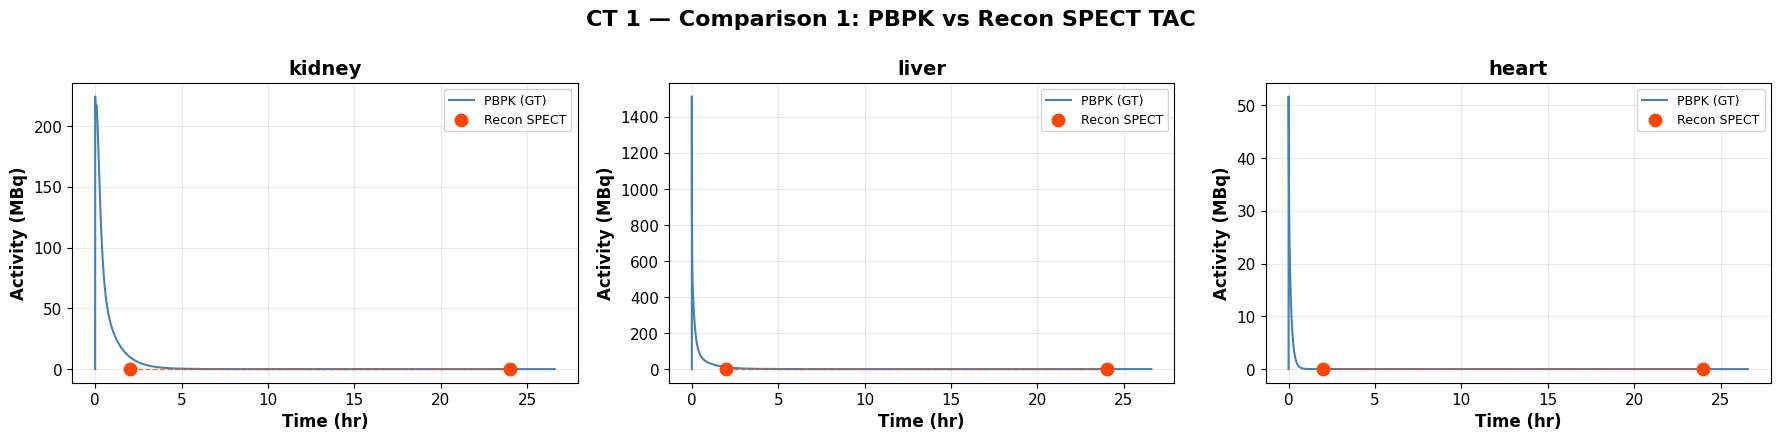

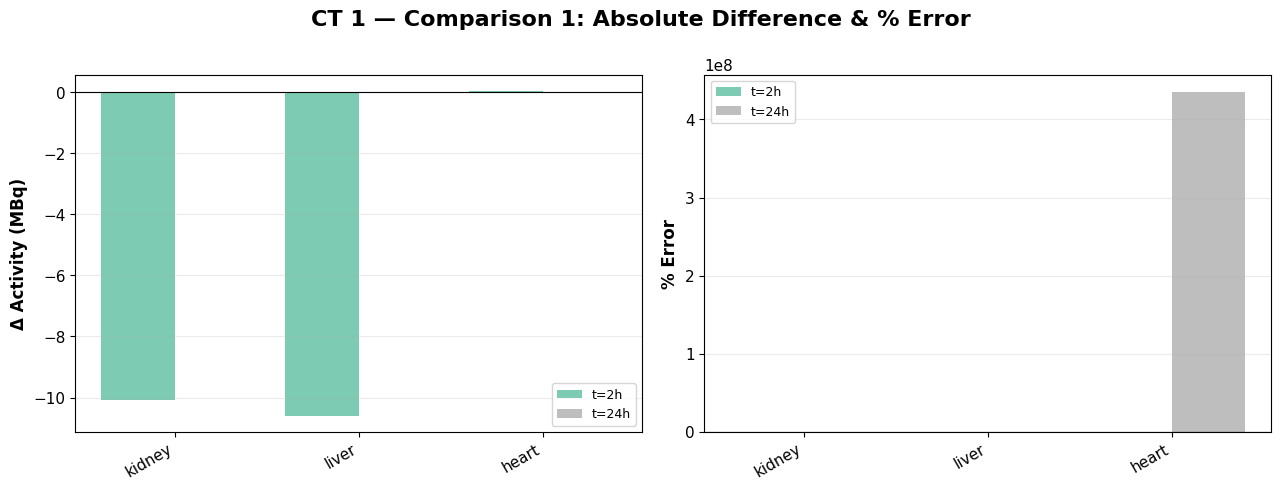

  ROI                   frame       PBPK      SPECT          Δ     %err
  kidney                   2h     10.073      0.000    -10.073   -100.0%
  kidney                  24h      0.000      0.000     -0.000    -10.1%
  liver                    2h     10.591      0.000    -10.591   -100.0%
  liver                   24h      0.000      0.000     +0.000  +360240.0%
  heart                    2h      0.000      0.037     +0.037  +67881.5%
  heart                   24h     -0.000      0.004     +0.004  +435563135.1%


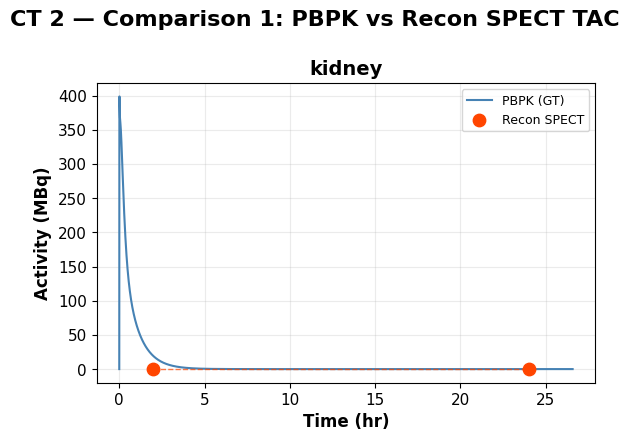

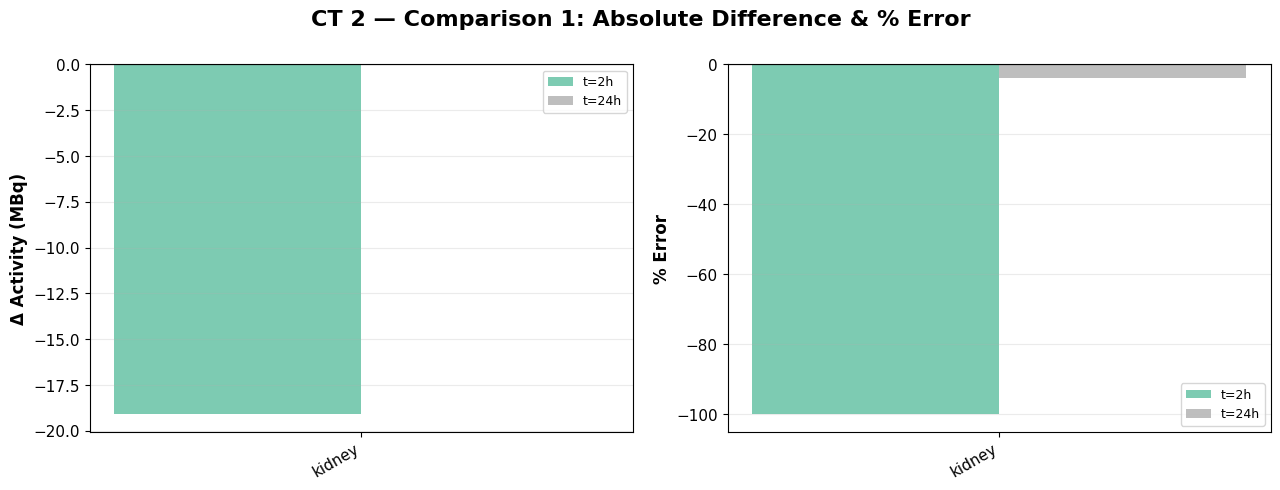

  ROI                   frame       PBPK      SPECT          Δ     %err
  kidney                   2h     19.097      0.000    -19.097   -100.0%
  kidney                  24h      0.000      0.000     -0.000     -4.0%


In [87]:
diff_store = {}   # {i: {roi: {'diff_mbq': arr, 'pct_err': arr, 'frame_hr': arr}}}

for i in spect_tacs:
    if i not in pbpk_store: continue
    diff_store[i] = {}
    pbpk_t = pbpk_store[i]['time_hr']

    for roi in spect_tacs[i]:
        if roi in SKIP_ROIS_COMPARISON: continue
        if not spect_tacs[i][roi]['sum_mbq']: continue
        pbpk_key = roi.lower()
        if pbpk_key not in pbpk_store[i]: continue

        t_hr  = np.array(spect_tacs[i][roi]['frame_hr'])
        y_s   = np.array(spect_tacs[i][roi]['sum_mbq'])
        # interpolate PBPK at SPECT frame times
        y_p   = np.interp(t_hr, pbpk_t, pbpk_store[i][pbpk_key])

        if SKIP_LAST_FRAME and len(t_hr) > 1:
            t_hr, y_s, y_p = t_hr[:-1], y_s[:-1], y_p[:-1]

        diff_store[i][roi] = {
            'frame_hr' : t_hr,
            'diff_mbq' : y_s - y_p,
            'pct_err'  : pct(y_s, y_p),
            'y_spect'  : y_s,
            'y_pbpk'   : y_p,
        }

# ── per-patient plots ─────────────────────────────────────────────────────────
for i, diffs in diff_store.items():
    plot_rois = [r for r in diffs]
    if not plot_rois: continue
    pbpk_t = pbpk_store[i]['time_hr']

    # --- A: TAC overlay ---
    ncols = min(len(plot_rois), 4)
    nrows = max(1, (len(plot_rois) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
    fig.suptitle(f'CT {i+1} — Comparison 1: PBPK vs Recon SPECT TAC')

    for j, roi in enumerate(plot_rois):
        ax = axes[j // ncols][j % ncols]
        d  = diffs[roi]
        ax.plot(pbpk_t, pbpk_store[i][roi.lower()], lw=1.5, color='steelblue', label='PBPK (GT)')
        ax.scatter(d['frame_hr'], d['y_spect'], s=80, color='orangered', zorder=5, label='Recon SPECT')
        ax.plot(d['frame_hr'], d['y_spect'], '--', color='orangered', lw=1, alpha=0.7)
        ax.set_title(roi.replace('_',' '))
        ax.set_xlabel('Time (hr)'); ax.set_ylabel('Activity (MBq)')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

    for j in range(len(plot_rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    plt.tight_layout(); plt.show()

    # --- B: Difference & % error bars ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'CT {i+1} — Comparison 1: Absolute Difference & % Error')

    x  = np.arange(len(plot_rois))
    w  = 0.8 / max(len(diffs[plot_rois[0]]['frame_hr']), 1)
    fr = diffs[plot_rois[0]]['frame_hr']
    fr_colors = plt.cm.Set2(np.linspace(0, 1, len(fr)))

    for f_idx, (ft, fc) in enumerate(zip(fr, fr_colors)):
        dvals = [diffs[r]['diff_mbq'][f_idx] if f_idx < len(diffs[r]['diff_mbq']) else 0 for r in plot_rois]
        evals = [diffs[r]['pct_err'][f_idx]  if f_idx < len(diffs[r]['pct_err'])  else 0 for r in plot_rois]
        off   = (f_idx - len(fr)/2 + 0.5) * w
        axes[0].bar(x + off, dvals, w, color=fc, alpha=0.85, label=f't={ft:.0f}h')
        axes[1].bar(x + off, evals, w, color=fc, alpha=0.85, label=f't={ft:.0f}h')

    for ax, ylabel in zip(axes, ['Δ Activity (MBq)', '% Error']):
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([r.replace('_',' ') for r in plot_rois], rotation=30, ha='right')
        ax.set_ylabel(ylabel); ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.25)

    plt.tight_layout(); plt.show()

    # print table
    print(f"  {'ROI':20s} {'frame':>6s}  {'PBPK':>9s}  {'SPECT':>9s}  {'Δ':>9s}  {'%err':>7s}")
    for roi in plot_rois:
        d = diffs[roi]
        for f_idx in range(len(d['frame_hr'])):
            print(f"  {roi:20s} {d['frame_hr'][f_idx]:5.0f}h  "
                  f"{d['y_pbpk'][f_idx]:9.3f}  {d['y_spect'][f_idx]:9.3f}  "
                  f"{d['diff_mbq'][f_idx]:+9.3f}  {d['pct_err'][f_idx]:+7.1f}%")

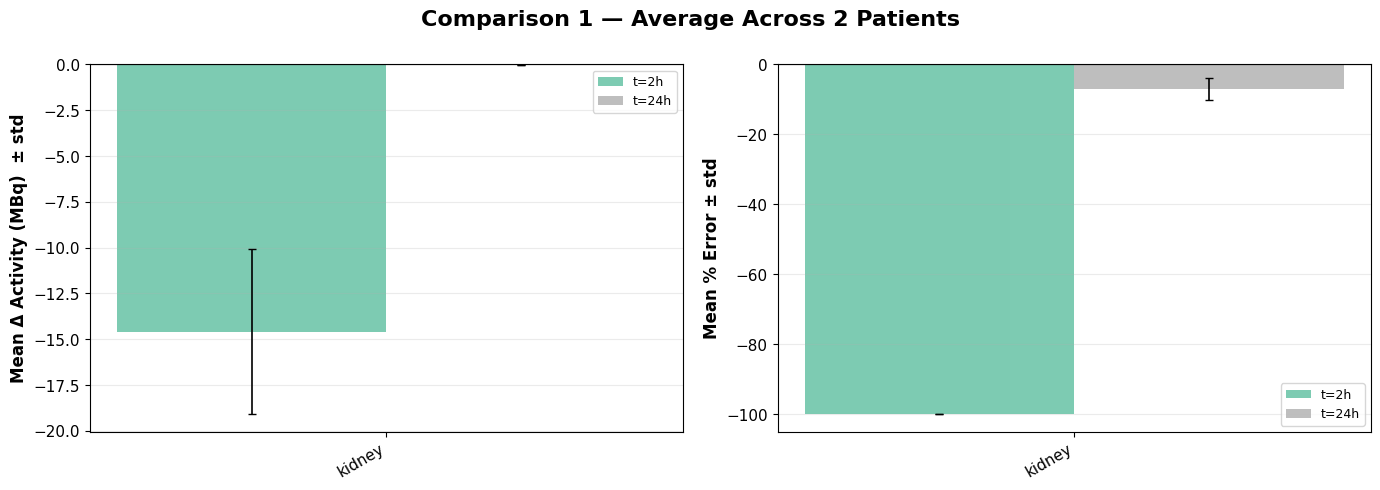

In [88]:
# ── Comparison 1: Average across patients ─────────────────────────────────────
if len(diff_store) > 1:
    all_rois_c1 = sorted(set.intersection(*[set(diff_store[i].keys()) for i in diff_store]))
    n_frames_c1 = min(len(diff_store[i][all_rois_c1[0]]['frame_hr']) for i in diff_store)

    avg_diff, avg_err, std_diff, std_err = {}, {}, {}, {}
    for roi in all_rois_c1:
        d_stack = np.array([diff_store[i][roi]['diff_mbq'][:n_frames_c1] for i in diff_store])
        e_stack = np.array([diff_store[i][roi]['pct_err'][:n_frames_c1]  for i in diff_store])
        avg_diff[roi] = np.mean(d_stack, axis=0)
        avg_err[roi]  = np.mean(e_stack, axis=0)
        std_diff[roi] = np.std(d_stack,  axis=0)
        std_err[roi]  = np.std(e_stack,  axis=0)

    fr_ref = diff_store[list(diff_store.keys())[0]][all_rois_c1[0]]['frame_hr'][:n_frames_c1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Comparison 1 — Average Across {len(diff_store)} Patients')
    x = np.arange(len(all_rois_c1))
    w = 0.8 / max(n_frames_c1, 1)
    fr_colors = plt.cm.Set2(np.linspace(0, 1, n_frames_c1))

    for f_idx, fc in enumerate(fr_colors):
        dvals = [avg_diff[r][f_idx] for r in all_rois_c1]
        evals = [avg_err[r][f_idx]  for r in all_rois_c1]
        dsdev = [std_diff[r][f_idx] for r in all_rois_c1]
        esdev = [std_err[r][f_idx]  for r in all_rois_c1]
        off   = (f_idx - n_frames_c1/2 + 0.5) * w
        axes[0].bar(x + off, dvals, w, color=fc, alpha=0.85, label=f't={fr_ref[f_idx]:.0f}h',
                    yerr=dsdev, capsize=3, error_kw={'lw':1.2})
        axes[1].bar(x + off, evals, w, color=fc, alpha=0.85, label=f't={fr_ref[f_idx]:.0f}h',
                    yerr=esdev, capsize=3, error_kw={'lw':1.2})

    for ax, ylabel in zip(axes, ['Mean Δ Activity (MBq)  ± std', 'Mean % Error ± std']):
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([r.replace('_',' ') for r in all_rois_c1], rotation=30, ha='right')
        ax.set_ylabel(ylabel); ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout(); plt.show()
else:
    print('Only 1 patient — cross-patient average skipped')

---
### Comparison 2 — Bi-exponential Kinetics: PBPK vs Recon SPECT

  CT 1 kidney SPECT fit failed: Need ≥3 points, got 2
  CT 1 liver SPECT fit failed: Need ≥3 points, got 2
  CT 1 heart SPECT fit failed: Need ≥3 points, got 2


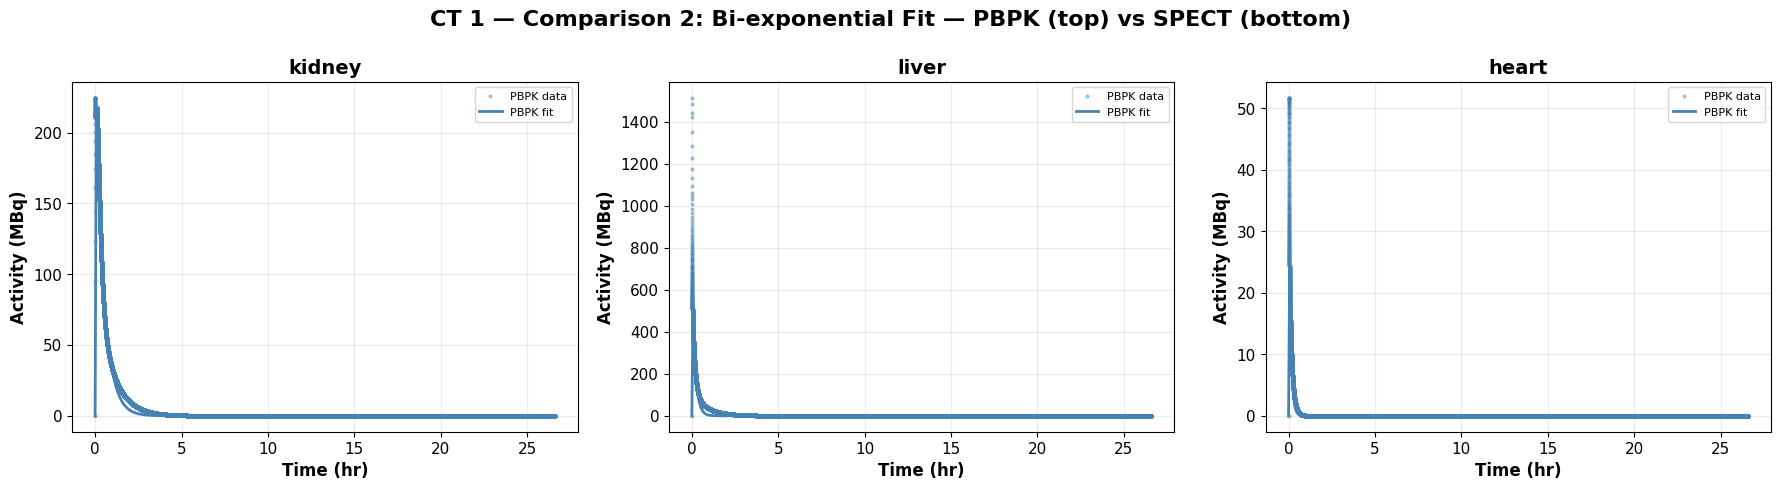


  CT 1 — Kinetic Parameter Comparison
  ROI                   k_slow_PBPK  k_slow_SPECT  Δk_slow%   k_fast_PBPK  k_fast_SPECT  Δk_fast%
  CT 2 kidney SPECT fit failed: Need ≥3 points, got 2


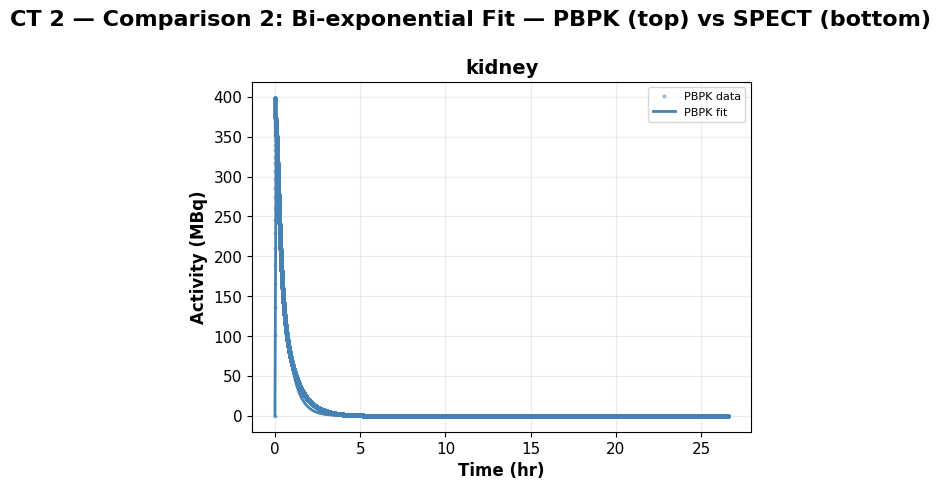


  CT 2 — Kinetic Parameter Comparison
  ROI                   k_slow_PBPK  k_slow_SPECT  Δk_slow%   k_fast_PBPK  k_fast_SPECT  Δk_fast%


In [89]:
def biexp(t, A, k_slow, delta):
    """Bi-exponential through origin: A*(exp(-k_slow*t) - exp(-(k_slow+delta)*t))."""
    return A * (np.exp(-k_slow * t) - np.exp(-(k_slow + delta) * t))

def fit_biexp(t, y):
    t, y = np.asarray(t, float), np.asarray(y, float)
    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]
    if t.size < 3:
        raise ValueError(f'Need ≥3 points, got {t.size}')
    p0     = [float(np.max(y)), 0.05, 1.0]
    bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])
    popt, _ = curve_fit(biexp, t, y, p0=p0, bounds=bounds, maxfev=50000)
    return popt   # A, k_slow, delta  (1/hr)


fit_store = {}   # {i: {roi: {'pbpk': popt, 'spect': popt}}}

for i in spect_tacs:
    if i not in pbpk_store: continue
    fit_store[i] = {}
    pbpk_t = pbpk_store[i]['time_hr']

    plot_rois = [r for r in spect_tacs[i]
                 if r not in SKIP_ROIS_COMPARISON
                 and r.lower() in pbpk_store[i]
                 and len(spect_tacs[i][r]['sum_mbq']) >= 3]

    if not plot_rois:
        print(f'CT {i+1}: insufficient frames for bi-exp fit (need ≥3)'); continue

    ncols = min(len(plot_rois), 4)
    nrows = max(1, (len(plot_rois) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    fig.suptitle(f'CT {i+1} — Comparison 2: Bi-exponential Fit — PBPK (top) vs SPECT (bottom)')

    t_grid = np.linspace(0, pbpk_t[-1], 400)

    for j, roi in enumerate(plot_rois):
        ax = axes[j // ncols][j % ncols]

        # PBPK fit
        y_pbpk = pbpk_store[i][roi.lower()]
        try:
            popt_p = fit_biexp(pbpk_t, y_pbpk)
            ax.plot(pbpk_t, y_pbpk, 'o', ms=2, color='steelblue', alpha=0.4, label='PBPK data')
            ax.plot(t_grid, biexp(t_grid, *popt_p), lw=2, color='steelblue', label='PBPK fit')
        except Exception as e:
            popt_p = None; print(f'  CT {i+1} {roi} PBPK fit failed: {e}')

        # SPECT fit
        t_s  = np.array(spect_tacs[i][roi]['frame_hr'])
        y_s  = np.array(spect_tacs[i][roi]['sum_mbq'])
        if SKIP_LAST_FRAME and len(t_s) > 1:
            t_s, y_s = t_s[:-1], y_s[:-1]
        try:
            popt_s = fit_biexp(t_s, y_s)
            ax.scatter(t_s, y_s, s=80, color='orangered', zorder=5, label='SPECT data')
            ax.plot(t_grid, biexp(t_grid, *popt_s), '--', lw=2, color='orangered', label='SPECT fit')
        except Exception as e:
            popt_s = None; print(f'  CT {i+1} {roi} SPECT fit failed: {e}')

        if popt_p is not None and popt_s is not None:
            fit_store[i][roi] = {'pbpk': popt_p, 'spect': popt_s}
            kf_p = popt_p[1] + popt_p[2]
            kf_s = popt_s[1] + popt_s[2]
            ax.set_title(f"{roi.replace('_',' ')}\n"
                         f"k_slow: PBPK={popt_p[1]:.3f} SPECT={popt_s[1]:.3f}  "
                         f"k_fast: PBPK={kf_p:.3f} SPECT={kf_s:.3f} [1/hr]", fontsize=9)
        else:
            ax.set_title(roi.replace('_',' '))

        ax.set_xlabel('Time (hr)'); ax.set_ylabel('Activity (MBq)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

    for j in range(len(plot_rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    plt.tight_layout(); plt.show()

    # kinetic parameter comparison table
    print(f"\n  CT {i+1} — Kinetic Parameter Comparison")
    print(f"  {'ROI':20s} {'k_slow_PBPK':>12s} {'k_slow_SPECT':>13s} {'Δk_slow%':>9s}  "
          f"{'k_fast_PBPK':>12s} {'k_fast_SPECT':>13s} {'Δk_fast%':>9s}")
    for roi, fits in fit_store.get(i, {}).items():
        pp, ps = fits['pbpk'], fits['spect']
        ks_p, ks_s = pp[1], ps[1]
        kf_p, kf_s = pp[1]+pp[2], ps[1]+ps[2]
        print(f"  {roi:20s} {ks_p:12.4f} {ks_s:13.4f} {pct(ks_s,ks_p):+9.1f}%  "
              f"{kf_p:12.4f} {kf_s:13.4f} {pct(kf_s,kf_p):+9.1f}%")

In [90]:
# ── Comparison 2: Average kinetic params across patients ──────────────────────
if len(fit_store) > 1:
    all_rois_c2 = sorted(set.intersection(*[set(fit_store[i].keys()) for i in fit_store
                                            if fit_store[i]]))
    param_names = ['k_slow', 'k_fast']

    acc = {roi: {p: {'pbpk':[], 'spect':[], 'diff':[], 'pct':[]} for p in param_names}
           for roi in all_rois_c2}

    for i in fit_store:
        for roi in all_rois_c2:
            if roi not in fit_store[i]: continue
            pp, ps = fit_store[i][roi]['pbpk'], fit_store[i][roi]['spect']
            for pname, vp, vs in [
                ('k_slow', pp[1],        ps[1]),
                ('k_fast', pp[1]+pp[2],  ps[1]+ps[2]),
            ]:
                acc[roi][pname]['pbpk'].append(vp)
                acc[roi][pname]['spect'].append(vs)
                acc[roi][pname]['diff'].append(vs - vp)
                acc[roi][pname]['pct'].append(pct(vs, vp))

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(f'Comparison 2 — Mean Kinetic Parameters Across {len(fit_store)} Patients')
    x = np.arange(len(all_rois_c2))

    for row, pname in enumerate(param_names):
        means_p = [np.mean(acc[r][pname]['pbpk'])  for r in all_rois_c2]
        means_s = [np.mean(acc[r][pname]['spect']) for r in all_rois_c2]
        stds_p  = [np.std(acc[r][pname]['pbpk'])   for r in all_rois_c2]
        stds_s  = [np.std(acc[r][pname]['spect'])  for r in all_rois_c2]
        pcts    = [np.mean(acc[r][pname]['pct'])   for r in all_rois_c2]
        pct_sd  = [np.std(acc[r][pname]['pct'])    for r in all_rois_c2]

        ax = axes[row][0]
        ax.bar(x - 0.2, means_p, 0.4, yerr=stds_p,  label='PBPK',  color='steelblue', alpha=0.85, capsize=4)
        ax.bar(x + 0.2, means_s, 0.4, yerr=stds_s,  label='SPECT', color='orangered', alpha=0.85, capsize=4)
        ax.set_xticks(x); ax.set_xticklabels([r.replace('_',' ') for r in all_rois_c2], rotation=30, ha='right')
        ax.set_ylabel(f'{pname} (1/hr)'); ax.set_title(f'{pname} — mean ± std'); ax.legend(); ax.grid(True, axis='y', alpha=0.25)

        ax2 = axes[row][1]
        colors_bar = ['tomato' if v > 0 else 'steelblue' for v in pcts]
        ax2.bar(x, pcts, yerr=pct_sd, color=colors_bar, alpha=0.85, capsize=4)
        ax2.axhline(0, color='k', lw=0.8)
        ax2.set_xticks(x); ax2.set_xticklabels([r.replace('_',' ') for r in all_rois_c2], rotation=30, ha='right')
        ax2.set_ylabel('% Error (SPECT vs PBPK)'); ax2.set_title(f'{pname} — mean % error ± std'); ax2.grid(True, axis='y', alpha=0.25)

    plt.tight_layout(); plt.show()
else:
    print('Only 1 patient — cross-patient average skipped')

TypeError: unbound method set.intersection() needs an argument

---
### Comparison 3 — Area Under Curve (AUC): PBPK vs Recon SPECT

In [ ]:
def pbpk_auc(t_hr, y_mbq, t_end_hr):
    """Trapezoidal AUC of PBPK data from 0..t_end_hr (MBq·hr)."""
    t, y = np.asarray(t_hr, float), np.asarray(y_mbq, float)
    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]
    order = np.argsort(t); t, y = t[order], y[order]
    t_end_use = min(t_end_hr, t[-1])
    keep = t <= t_end_use
    tu, yu = t[keep], y[keep]
    if tu.size == 0: return np.nan
    if tu[-1] < t_end_use:
        tu = np.append(tu, t_end_use)
        yu = np.append(yu, float(np.interp(t_end_use, t, y)))
    return float(np.trapezoid(yu, tu))

def spect_auc_analytic(popt, t_end_hr):
    """Analytic AUC of biexp from 0..t_end (MBq·hr)."""
    A, ks, delta = [float(v) for v in popt]
    kf = ks + delta
    if not all(np.isfinite([A, ks, kf])) or ks <= 0 or kf <= 0:
        return np.nan
    T = float(t_end_hr)
    return A * ((1 - np.exp(-ks * T)) / ks - (1 - np.exp(-kf * T)) / kf)


auc_store = {}   # {i: {roi: {'pbpk_auc', 'spect_auc', 't_end_hr'}}}

for i in fit_store:
    if i not in pbpk_store: continue
    auc_store[i] = {}
    pbpk_t = pbpk_store[i]['time_hr']

    for roi, fits in fit_store[i].items():
        t_s = np.array(spect_tacs[i][roi]['frame_hr'])
        if SKIP_LAST_FRAME and len(t_s) > 1: t_s = t_s[:-1]
        t_end = float(t_s[-1]) if len(t_s) > 0 else float(pbpk_t[-1])

        auc_p = pbpk_auc(pbpk_t, pbpk_store[i][roi.lower()], t_end)
        auc_s = spect_auc_analytic(fits['spect'], t_end)

        auc_store[i][roi] = {'pbpk_auc': auc_p, 'spect_auc': auc_s, 't_end_hr': t_end}

# ── per-patient AUC plots ─────────────────────────────────────────────────────
for i, aucs in auc_store.items():
    if not aucs: continue
    rois = list(aucs.keys())
    x    = np.arange(len(rois))

    pbpk_vals  = [aucs[r]['pbpk_auc']  for r in rois]
    spect_vals = [aucs[r]['spect_auc'] for r in rois]
    diff_vals  = [aucs[r]['spect_auc'] - aucs[r]['pbpk_auc'] for r in rois]
    pct_vals   = [pct(aucs[r]['spect_auc'], aucs[r]['pbpk_auc']) for r in rois]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'CT {i+1} — Comparison 3: AUC (PBPK vs Recon SPECT)')

    axes[0].bar(x - 0.2, pbpk_vals,  0.4, color='steelblue', alpha=0.85, label='PBPK')
    axes[0].bar(x + 0.2, spect_vals, 0.4, color='orangered',  alpha=0.85, label='SPECT')
    axes[0].set_xticks(x); axes[0].set_xticklabels([r.replace('_',' ') for r in rois], rotation=30, ha='right')
    axes[0].set_ylabel('AUC (MBq·hr)'); axes[0].set_title('AUC values'); axes[0].legend(); axes[0].grid(True, axis='y', alpha=0.25)

    bar_colors = ['tomato' if v > 0 else 'steelblue' for v in diff_vals]
    axes[1].bar(x, diff_vals, color=bar_colors, alpha=0.85)
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels([r.replace('_',' ') for r in rois], rotation=30, ha='right')
    axes[1].set_ylabel('Δ AUC (MBq·hr)'); axes[1].set_title('Absolute difference'); axes[1].grid(True, axis='y', alpha=0.25)

    bar_colors = ['tomato' if v > 0 else 'steelblue' for v in pct_vals]
    axes[2].bar(x, pct_vals, color=bar_colors, alpha=0.85)
    axes[2].axhline(0, color='k', lw=0.8)
    axes[2].set_xticks(x); axes[2].set_xticklabels([r.replace('_',' ') for r in rois], rotation=30, ha='right')
    axes[2].set_ylabel('% Error'); axes[2].set_title('% Error (SPECT vs PBPK)'); axes[2].grid(True, axis='y', alpha=0.25)

    plt.tight_layout(); plt.show()

    print(f"  CT {i+1} — {'ROI':20s} {'PBPK AUC':>12s} {'SPECT AUC':>12s} {'Δ':>10s} {'%err':>8s}")
    for roi in rois:
        a = aucs[roi]
        print(f"  {'':3s} {roi:20s} {a['pbpk_auc']:12.3f} {a['spect_auc']:12.3f} "
              f"{a['spect_auc']-a['pbpk_auc']:+10.3f} {pct(a['spect_auc'],a['pbpk_auc']):+8.1f}%")

In [ ]:
# ── Comparison 3: Average AUC across patients ─────────────────────────────────
if len(auc_store) > 1:
    all_rois_c3 = sorted(set.intersection(*[set(auc_store[i].keys()) for i in auc_store if auc_store[i]]))
    roi_acc = {r: {'pbpk':[], 'spect':[], 'diff':[], 'pct':[]} for r in all_rois_c3}

    for i in auc_store:
        for roi in all_rois_c3:
            if roi not in auc_store[i]: continue
            a = auc_store[i][roi]
            roi_acc[roi]['pbpk'].append(a['pbpk_auc'])
            roi_acc[roi]['spect'].append(a['spect_auc'])
            roi_acc[roi]['diff'].append(a['spect_auc'] - a['pbpk_auc'])
            roi_acc[roi]['pct'].append(pct(a['spect_auc'], a['pbpk_auc']))

    x = np.arange(len(all_rois_c3))
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Comparison 3 — Mean AUC Across {len(auc_store)} Patients')

    mp = [np.mean(roi_acc[r]['pbpk'])  for r in all_rois_c3]
    ms = [np.mean(roi_acc[r]['spect']) for r in all_rois_c3]
    sp_ = [np.std(roi_acc[r]['pbpk'])  for r in all_rois_c3]
    ss  = [np.std(roi_acc[r]['spect']) for r in all_rois_c3]
    md  = [np.mean(roi_acc[r]['diff']) for r in all_rois_c3]
    sd  = [np.std(roi_acc[r]['diff'])  for r in all_rois_c3]
    me  = [np.mean(roi_acc[r]['pct'])  for r in all_rois_c3]
    se  = [np.std(roi_acc[r]['pct'])   for r in all_rois_c3]

    axes[0].bar(x-0.2, mp, 0.4, yerr=sp_, capsize=4, color='steelblue', alpha=0.85, label='PBPK')
    axes[0].bar(x+0.2, ms, 0.4, yerr=ss,  capsize=4, color='orangered',  alpha=0.85, label='SPECT')
    axes[0].set_xticks(x); axes[0].set_xticklabels([r.replace('_',' ') for r in all_rois_c3], rotation=30, ha='right')
    axes[0].set_ylabel('Mean AUC (MBq·hr)'); axes[0].set_title('AUC mean ± std'); axes[0].legend(); axes[0].grid(True, axis='y', alpha=0.25)

    axes[1].bar(x, md, yerr=sd, capsize=4, color=['tomato' if v>0 else 'steelblue' for v in md], alpha=0.85)
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels([r.replace('_',' ') for r in all_rois_c3], rotation=30, ha='right')
    axes[1].set_ylabel('Δ AUC mean ± std (MBq·hr)'); axes[1].set_title('Mean diff'); axes[1].grid(True, axis='y', alpha=0.25)

    axes[2].bar(x, me, yerr=se, capsize=4, color=['tomato' if v>0 else 'steelblue' for v in me], alpha=0.85)
    axes[2].axhline(0, color='k', lw=0.8)
    axes[2].set_xticks(x); axes[2].set_xticklabels([r.replace('_',' ') for r in all_rois_c3], rotation=30, ha='right')
    axes[2].set_ylabel('Mean % Error ± std'); axes[2].set_title('Mean % error'); axes[2].grid(True, axis='y', alpha=0.25)

    plt.tight_layout(); plt.show()

    print(f"  {'ROI':20s} {'PBPK mean':>12s} {'SPECT mean':>12s} {'Δ mean':>10s} {'%err mean':>12s}")
    for roi in all_rois_c3:
        print(f"  {roi:20s} {np.mean(roi_acc[roi]['pbpk']):12.3f} "
              f"{np.mean(roi_acc[roi]['spect']):12.3f} "
              f"{np.mean(roi_acc[roi]['diff']):+10.3f} "
              f"{np.mean(roi_acc[roi]['pct']):+12.1f}%")
else:
    print('Only 1 patient — cross-patient average skipped')

Only 1 patient — cross-patient average skipped


---
## 7 — CPU & RAM Profiling
Requires pipeline run with `--profile`. Set `PROFILE_PHASE` at the top to filter by stage name.

In [92]:
profiles = {}
for i, folder in enumerate(OUT_FOLDERS):
    hits = [
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.startswith('profiling_CT_') and f.endswith('.json')
    ] if os.path.isdir(folder) else []
    if not hits:
        print(f'CT {i+1}: no profiling file (run with --profile)'); continue
    with open(hits[0]) as f:
        profiles[i] = json.load(f)
    stages = [s['name'] for s in profiles[i]['stages']]
    print(f'CT {i+1}: {len(stages)} stages, total={profiles[i]["pipeline_total_elapsed_s"]:.1f}s')
    print(f'  stages: {stages}')

if not profiles:
    print('\nNo profiling data available — re-run with --profile to enable.')

CT 1: 7 stages, total=28.6s
  stages: ['segmentation', 'synthetic_lesions', 'pbpk_tac', 'simind', 'opengate', 'spect_postprocess', 'dosemap_postprocess']
CT 2: 6 stages, total=3895.2s
  stages: ['segmentation', 'pbpk_tac', 'simind', 'opengate', 'spect_postprocess', 'dosemap_postprocess']


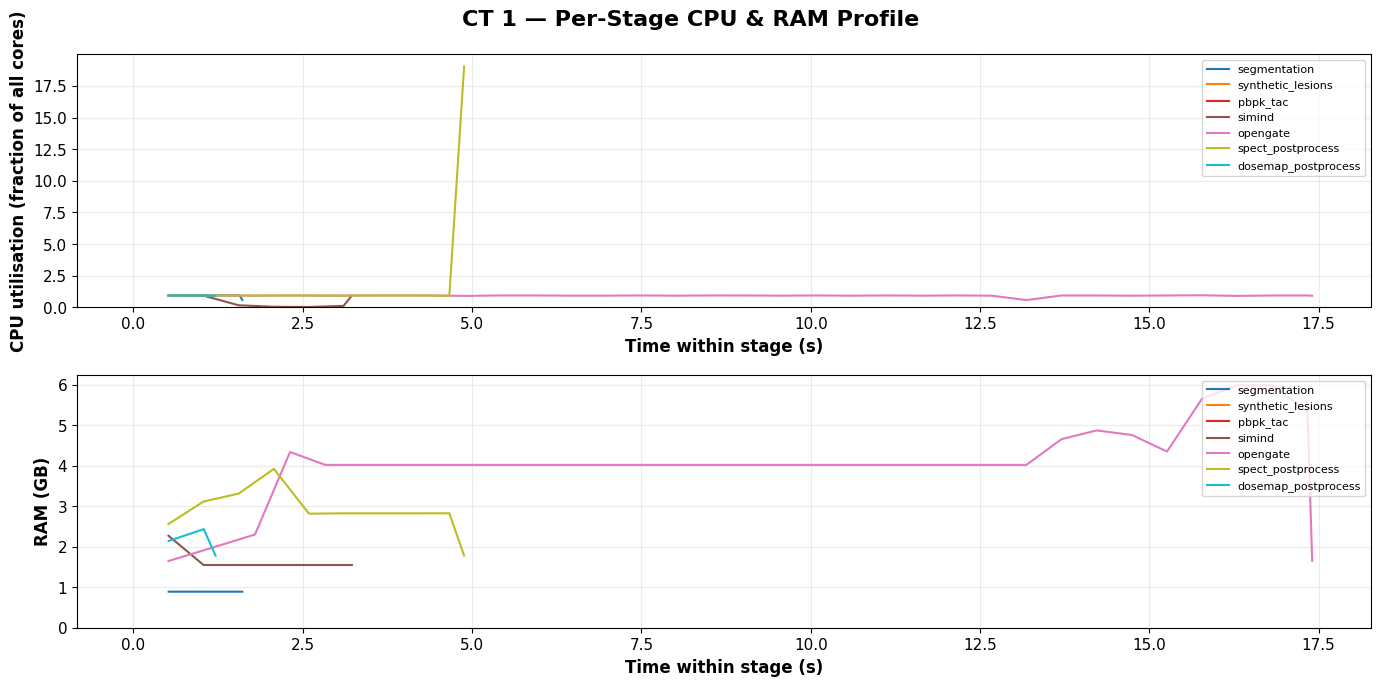

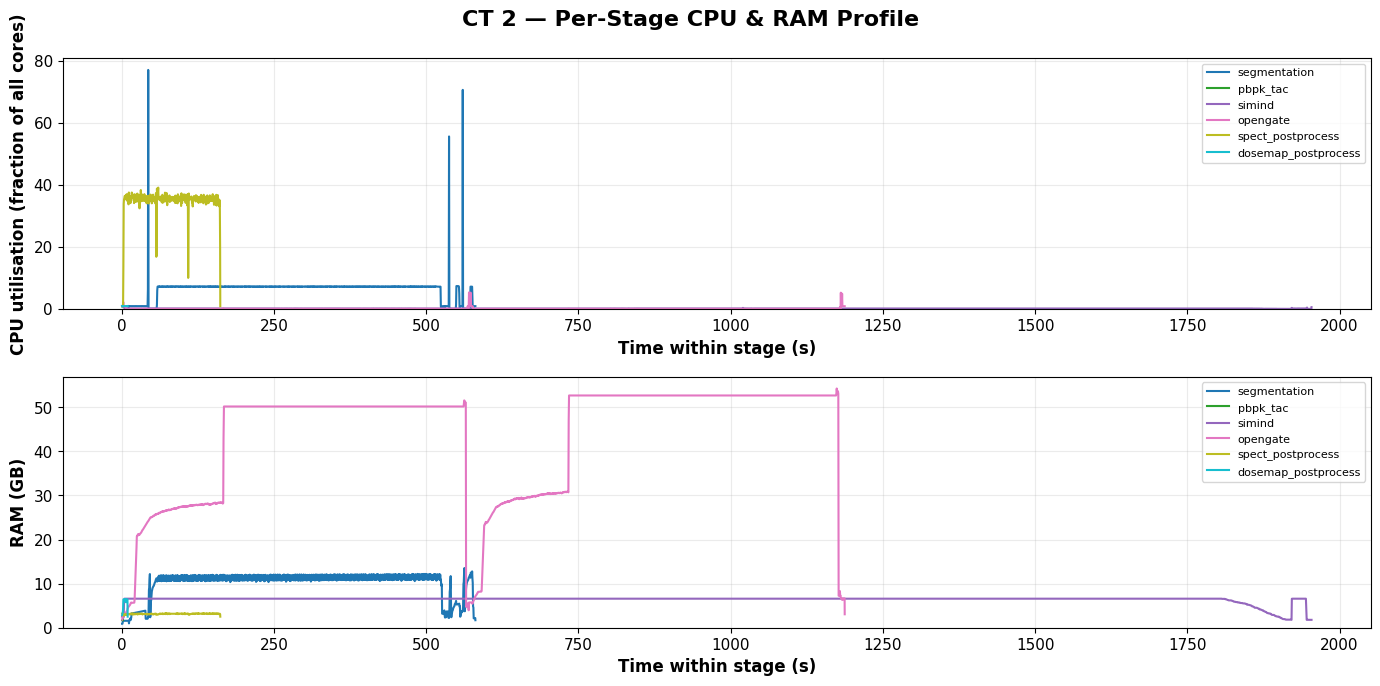

In [93]:
# ── Per-patient: CPU & RAM timeline ──────────────────────────────────────────
for i, prof in profiles.items():
    stages    = prof['stages']
    cpu_count = prof.get('logical_cpu_count', 1)
    if not stages: continue

    colors = plt.cm.tab10(np.linspace(0, 1, len(stages)))
    fig, (ax_cpu, ax_ram) = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
    fig.suptitle(f'CT {i+1} — Per-Stage CPU & RAM Profile')

    for s, col in zip(stages, colors):
        t   = s.get('sample_times_s', [])
        cpu = s.get('cpu_pct_samples', [])
        ram = s.get('ram_mb_samples', [])
        if not t: continue
        name = s.get('name', 'unknown')
        cpu_norm = [c / cpu_count for c in cpu]
        ax_cpu.plot(t, cpu_norm, lw=1.5, color=col, label=name)
        ax_ram.plot(t, [r / 1024.0 for r in ram], lw=1.5, color=col, label=name)

    ax_cpu.set_ylabel('CPU utilisation (fraction of all cores)')
    ax_cpu.set_xlabel('Time within stage (s)')
    ax_cpu.legend(fontsize=8, loc='upper right'); ax_cpu.grid(True, alpha=0.25); ax_cpu.set_ylim(bottom=0)

    ax_ram.set_ylabel('RAM (GB)')
    ax_ram.set_xlabel('Time within stage (s)')
    ax_ram.legend(fontsize=8, loc='upper right'); ax_ram.grid(True, alpha=0.25); ax_ram.set_ylim(bottom=0)

    plt.tight_layout(); plt.show()

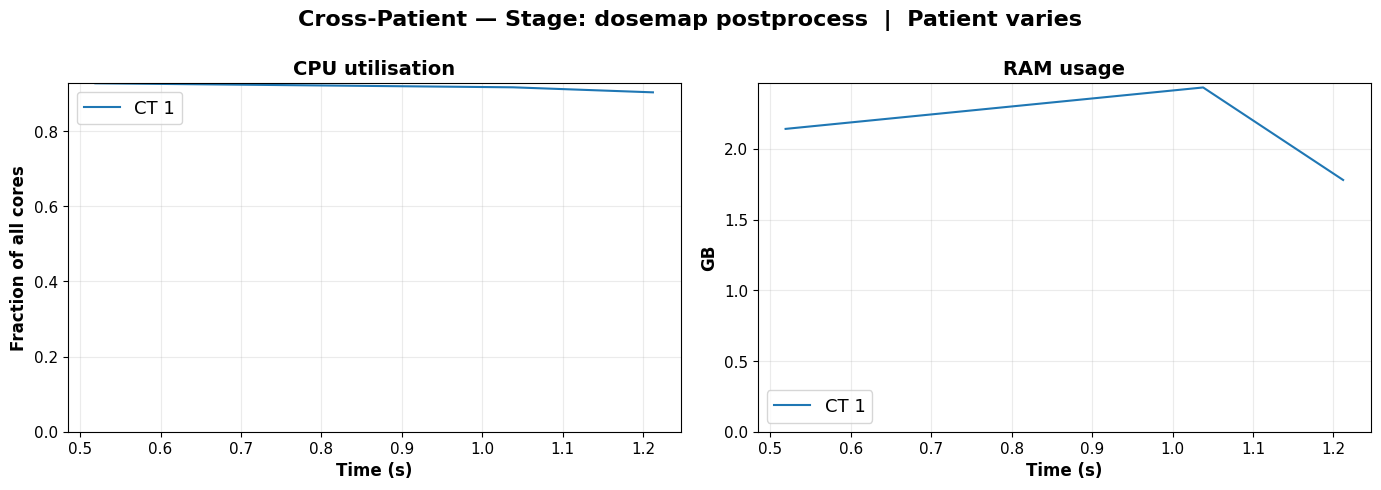

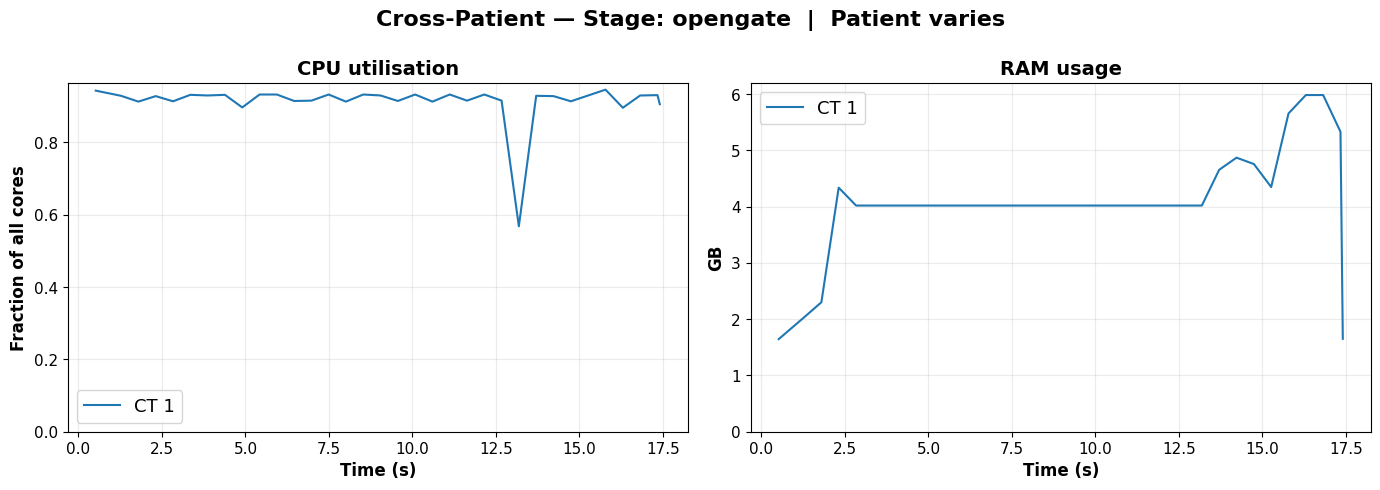

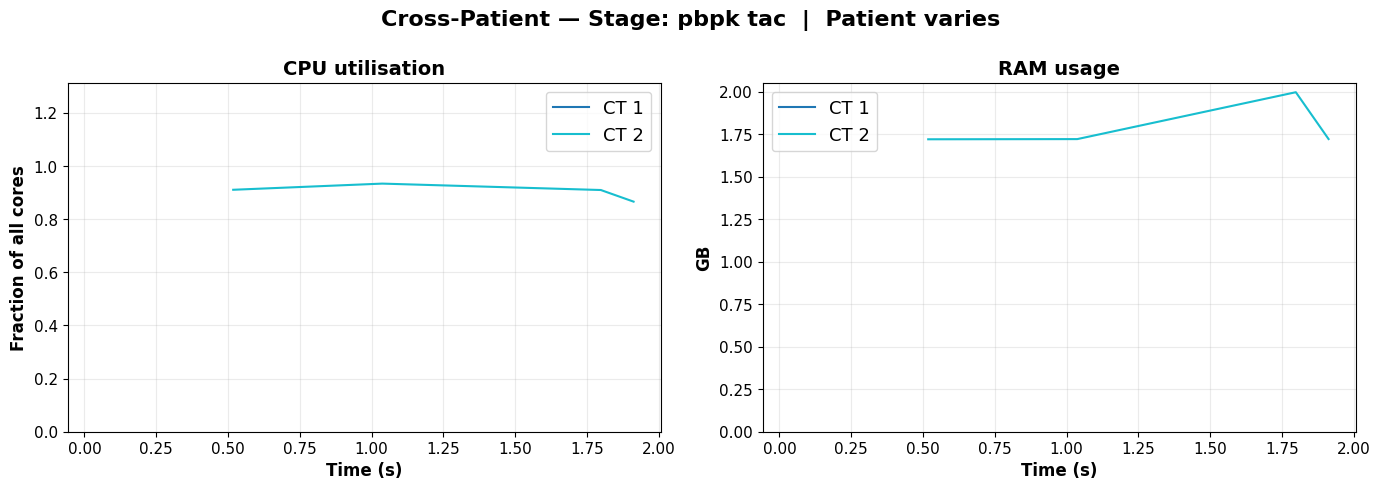

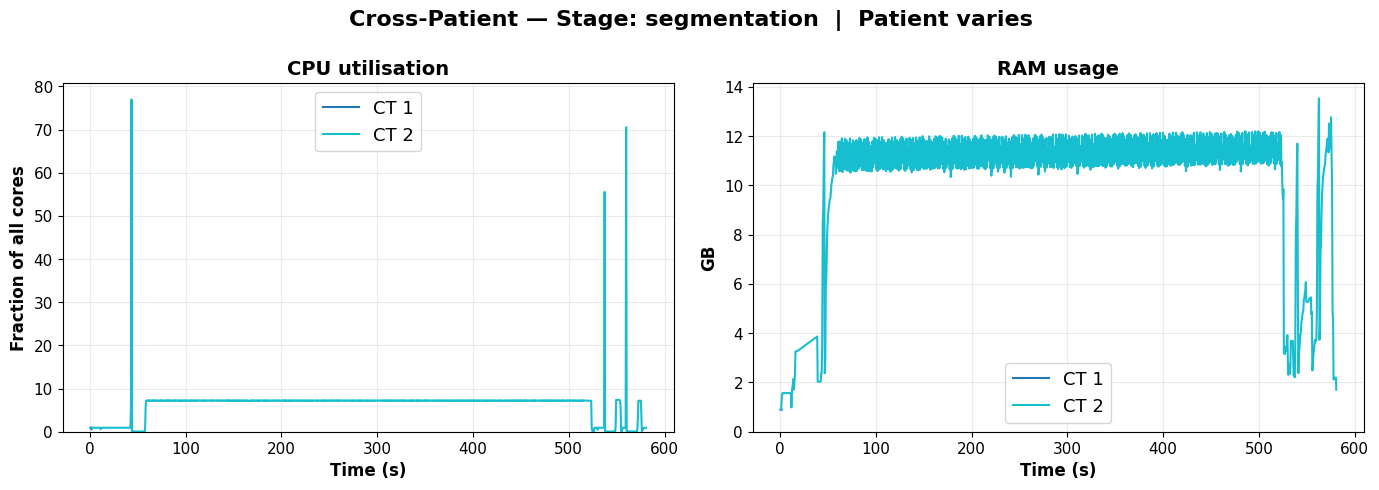

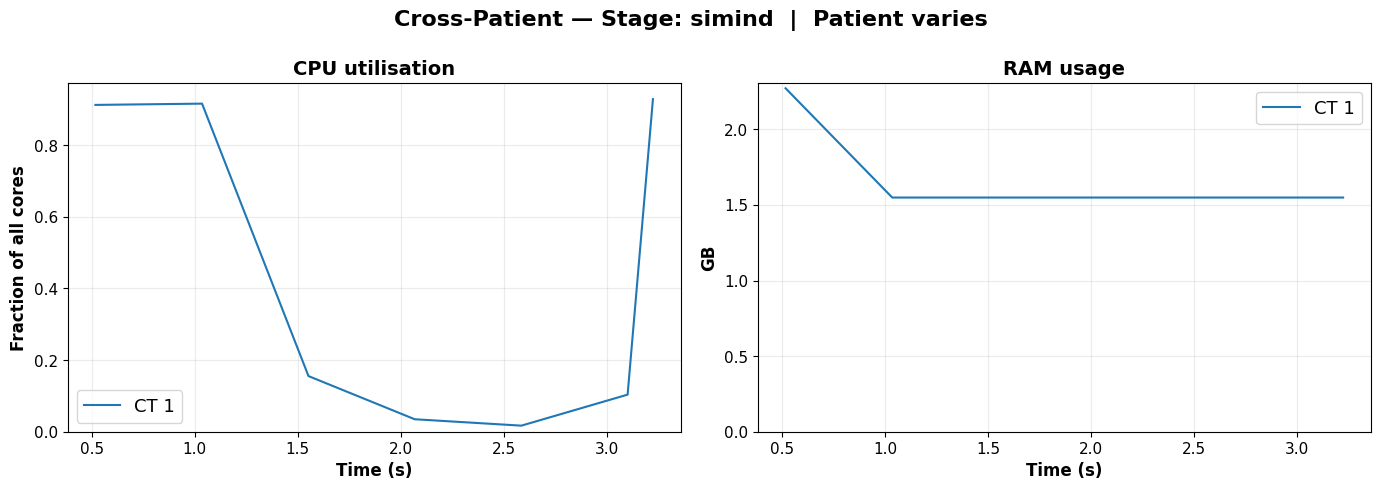

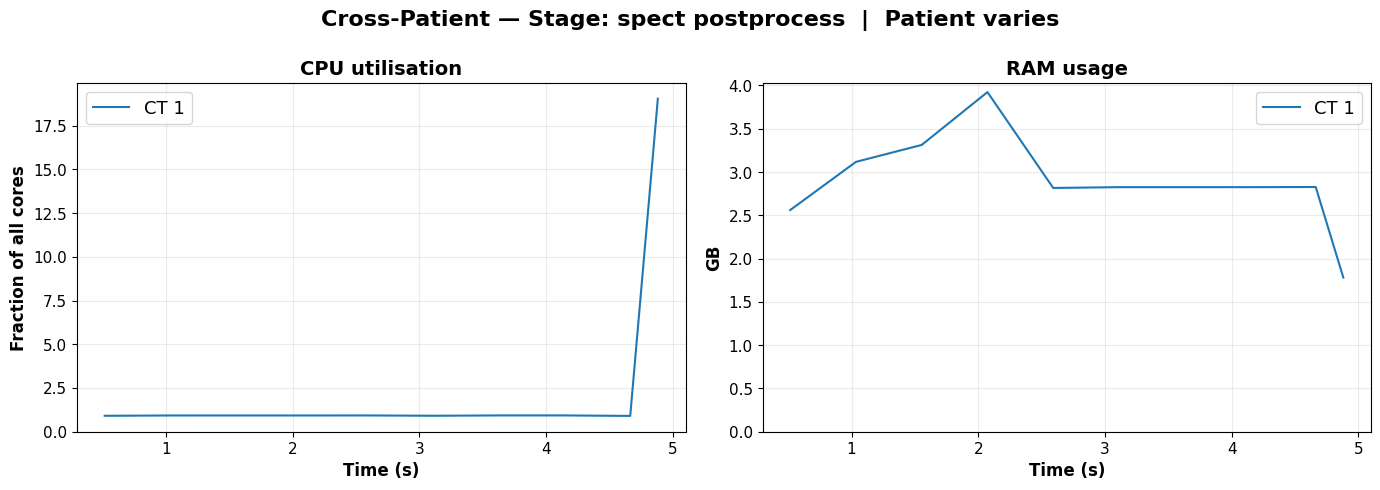

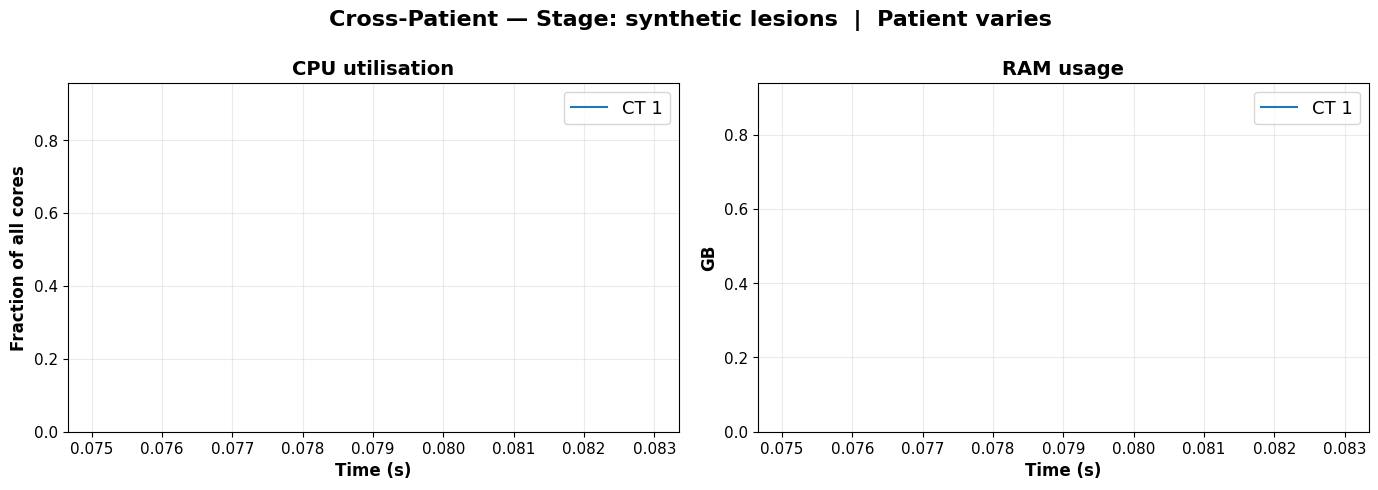

In [ ]:
# ── Cross-patient stage comparison ────────────────────────────────────────────
if len(profiles) > 1:
    def get_stages(prof, phase_filter):
        s = prof['stages']
        return [x for x in s if phase_filter.lower() in x.get('name','').lower()] if phase_filter else s

    all_stage_names = sorted({
        s['name'] for prof in profiles.values() for s in get_stages(prof, PROFILE_PHASE)
    })

    if not all_stage_names:
        print(f"No stages match PROFILE_PHASE='{PROFILE_PHASE}'")
    else:
        patient_idxs = sorted(profiles.keys())
        colors = plt.cm.tab10(np.linspace(0, 1, len(patient_idxs)))

        for stage_name in all_stage_names:
            fig, (ax_cpu, ax_ram) = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'Cross-Patient — Stage: {stage_name.replace("_"," ")}  |  {PARAM_LABEL} varies')

            for k, (idx, col) in enumerate(zip(patient_idxs, colors)):
                prof      = profiles[idx]
                cpu_count = prof.get('logical_cpu_count', 1)
                match     = [s for s in prof['stages'] if s.get('name') == stage_name]
                if not match: continue
                s   = match[0]
                t   = s.get('sample_times_s', [])
                cpu = [c / cpu_count for c in s.get('cpu_pct_samples', [])]
                ram = [r / 1024.0    for r in s.get('ram_mb_samples', [])]
                if not t: continue
                lbl = f'CT {idx+1}'
                ax_cpu.plot(t, cpu, lw=1.5, color=col, label=lbl)
                ax_ram.plot(t, ram, lw=1.5, color=col, label=lbl)

            ax_cpu.set_title('CPU utilisation'); ax_cpu.set_xlabel('Time (s)')
            ax_cpu.set_ylabel('Fraction of all cores'); ax_cpu.legend(); ax_cpu.grid(True, alpha=0.25); ax_cpu.set_ylim(bottom=0)
            ax_ram.set_title('RAM usage'); ax_ram.set_xlabel('Time (s)')
            ax_ram.set_ylabel('GB'); ax_ram.legend(); ax_ram.grid(True, alpha=0.25); ax_ram.set_ylim(bottom=0)

            plt.tight_layout(); plt.show()
else:
    print('Only 1 patient — cross-patient profiling comparison skipped')

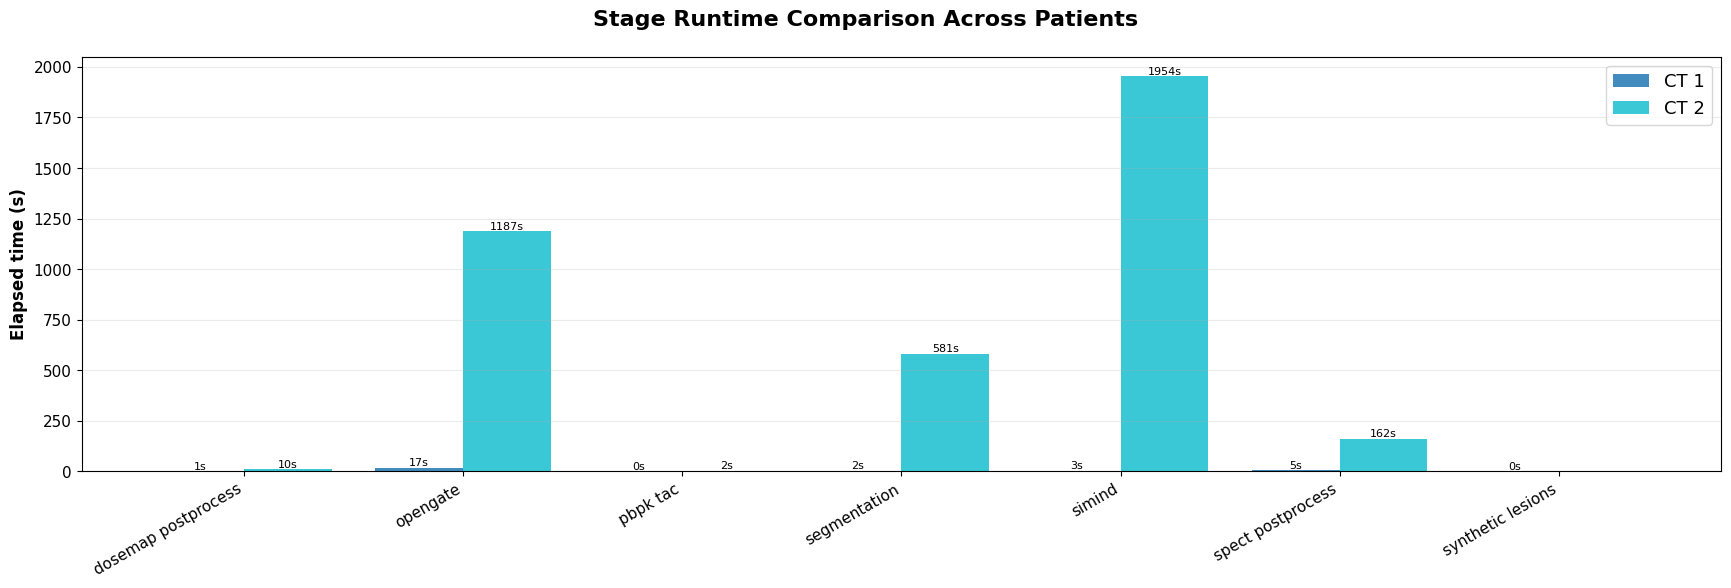

In [94]:
# ── Stage runtime bar chart ───────────────────────────────────────────────────
if profiles:
    all_names    = sorted({s['name'] for prof in profiles.values() for s in prof['stages']})
    patient_idxs = sorted(profiles.keys())
    x   = np.arange(len(all_names))
    w   = 0.8 / max(len(patient_idxs), 1)
    colors = plt.cm.tab10(np.linspace(0, 1, len(patient_idxs)))

    fig, ax = plt.subplots(figsize=(max(10, 2.5 * len(all_names)), 6))
    fig.suptitle('Stage Runtime Comparison Across Patients')

    for k, (idx, col) in enumerate(zip(patient_idxs, colors)):
        lookup   = {s['name']: s.get('elapsed_s', 0) for s in profiles[idx]['stages']}
        runtimes = [lookup.get(n, 0) for n in all_names]
        off = (k - len(patient_idxs)/2 + 0.5) * w
        bars = ax.bar(x + off, runtimes, w, label=f'CT {idx+1}', color=col, alpha=0.85)
        for bar, t_val in zip(bars, runtimes):
            if t_val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{t_val:.0f}s', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([n.replace('_stage','').replace('_',' ') for n in all_names],
                       rotation=30, ha='right')
    ax.set_ylabel('Elapsed time (s)'); ax.legend(); ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout(); plt.show()